# Исследование влияния образовательного онбординга на монетизацию (SollmaFin)

> Кратко: анализ A/B-теста обновлённого онбординга с образовательным блоком о финансовых рисках. Цель — оценить влияние фичи на конверсию в депозит, средний чек и удержание платящих пользователей на рынке Латинской Америки.

## Бизнес-контекст

**Продукт**: SollmaFin — мобильное приложение для торговли финансовыми активами (акции, валюта, криптовалюта, ETF). Целевая аудитория — начинающие инвесторы из четырёх стран Латинской Америки: Мексика, Бразилия, Колумбия, Аргентина.

**Проблема**: Анализ исторических данных выявил низкую финансовую грамотность пользователей: новички часто выбирают высокорискованные активы без понимания последствий, несут убытки и уходят после первого депозита. Это снижает пожизненную ценность клиента и общую монетизацию.

**Гипотеза продукта**: Детальный образовательный онбординг с информацией о типах активов и уровнях риска поможет пользователям принимать более взвешенные решения, что приведёт к:
- Более осознанному выбору активов
- Снижению оттока после убытков
- Росту числа повторных депозитов

**Риск внедрения**: Углублённый онбординг может увеличить трение на этапе регистрации и снизить конверсию в первый депозит, особенно среди осторожных пользователей.

**Задача анализа**: Провести полную оценку A/B-эксперимента, чтобы ответить на вопрос: перевешивает ли долгосрочная польза образовательного онбординга потенциальные краткосрочные потери в конверсии?

## Дизайн эксперимента

| Параметр | Значение |
|----------|----------|
| **Период регистрации** | 2–15 июня 2025 года |
| **Целевая аудитория** | Новые пользователи, впервые зарегистрировавшиеся в приложении |
| **Распределение** | Случайное, равномерное разделение на контрольную и тестовую группы |
| **Контрольная группа (A)** | Стандартный онбординг без обязательного обучения |
| **Тестовая группа (B)** | Обновлённый онбординг с блоком об активах и уровнях риска |
| **Период наблюдения** | 7 дней после регистрации |
| **География** | Мексика, Бразилия, Колумбия, Аргентина |

## Метрики оценки

| Тип метрики | Название | Формула / определение | Зачем нужна |
|-------------|----------|----------------------|-------------|
| **Ключевая** | Средняя сумма депозитов на пользователя | Σ amount / все пользователи | Оценивает общее влияние фичи на монетизацию, включая неплатящих |
| **Барьерная** | Конверсия в первый депозит | Пользователи с ≥1 депозитом / все пользователи | Гарантирует, что онбординг не создаёт избыточное трение на входе |
| **Вспомогательная 1** | Конверсия из первого депозита во второй | Пользователи с ≥2 депозитами / пользователи с ≥1 депозитом | Проверяет гипотезу о росте удержания платящих пользователей |
| **Вспомогательная 2** | Средняя сумма депозитов на платящего | Σ amount / пользователи с ≥1 депозитом | Показывает, меняется ли поведение тех, кто уже совершил покупку |

**Критерии успеха**:
- Барьерная метрика не снижается статистически значимо (или снижение компенсируется ростом вспомогательных)
- Вспомогательные метрики показывают положительную динамику
- Ключевая метрика растёт или остаётся стабильной

## Данные и методология

Анализ проведён на основе двух датасетов:

| Датасет | Период | Описание | Ключевые поля |
|---------|--------|----------|---------------|
| `pa_sollmafin_hist.csv` | 1 апреля – 1 июня 2025 | Исторические данные о поведении новых пользователей до второго депозита | `user_id`, `country_code`, `platform`, `event_name`, `amount`, `asset`, `risk_level` |
| `pa_sollmafin_abt.csv` | 2–15 июня 2025 | Данные A/B-эксперимента с распределением по группам | Все поля исторического датасета + `ab_test`, `group` |

**Методология анализа**:

1. **Исследовательский анализ исторических данных**
   - Сегментация пользователей по стране, платформе, уровню риска выбранных активов
   - Построение воронки: регистрация → первый депозит → выбор актива → второй депозит
   - Выявление паттернов, объясняющих низкую удерживаемость после первого депозита

2. **Оценка результатов A/B-теста**
   - Сравнение метрик между группами с расчётом доверительных интервалов
   - Проверка статистической значимости через бутстрап (1000 итераций) для метрик с асимметричным распределением (суммы депозитов)
   - Анализ влияния фичи на разные сегменты: по странам, платформам, уровню риска активов

3. **Глубокий анализ поведения платящих пользователей**
   - Сравнение распределений сумм депозитов через перцентили (10-й, 50-й, 90-й)
   - Оценка, как образовательный онбординг влияет на выбор активов с разным уровнем риска
   - Выявление точек роста: для каких сегментов фича работает лучше/хуже

**Ограничения**:
- Горизонт наблюдения — 7 дней: не оценивается долгосрочное удержание (>1 месяца)
- Эксперимент проводился только на новых пользователях: результаты не обобщаются на существующую базу
- Распределение сумм депозитов сильно асимметрично: для корректного сравнения используется бутстрап, а не параметрические тесты

## Ожидаемые результаты

По итогам анализа будут сформулированы:
1. Оценка статистической значимости изменений по всем метрикам
2. Сегментный анализ: для каких стран, платформ и типов пользователей фича работает эффективнее
3. Рекомендации по внедрению: масштабировать, оптимизировать или отклонить фичу
4. Гипотезы для дальнейших экспериментов: какие изменения в онбординге могут усилить положительный эффект

> Принцип интерпретации: решение о внедрении принимается на основе баланса между краткосрочными потерями (конверсия в первый депозит) и долгосрочными выгодами (удержание, повторные депозиты, качество выбора активов).


## 1. Загрузка и предобработка исторических данных

### Цель этапа
Подготовить исторические данные к исследовательскому анализу: обеспечить целостность, корректность типов и согласованность временных меток. Качество предобработки напрямую влияет на достоверность выводов о поведении пользователей и эффективности онбординга.

### Методология предобработки

| Направление | Что проверяем / приводим к единому формату | Пояснение |
|-------------|-------------------------------------------|-------------------|
| **Временные метки** | `first_ts`, `event_ts` → `datetime`; `first_dt` — контроль согласованности с датой первого события | Корректный расчёт временных интервалов: время до первого депозита, длительность сессии, когортная принадлежность |
| **Период анализа** | Фильтрация по `first_dt` в диапазоне 01.04.2025–01.06.2025 | Согласованность с дизайном эксперимента: исторические данные служат базой для сравнения с результатами A/B-теста |
| **Целостность событий** | Проверка логики последовательности: регистрация → депозит → выбор актива; фильтрация событий с `amount < 0` | Исключение артефактов сбора данных, которые могут исказить воронку конверсии и расчёт средних сумм |
| **Валидация категориальных признаков** | Приведение `country_code`, `platform`, `risk_level` к единому регистру; проверка на неизвестные значения | Корректная сегментация: ошибки в категориях приведут к неверному распределению пользователей по группам |
| **Обработка пропусков** | Анализ паттерна пропусков в `amount`, `asset`, `risk_level`; решение об исключении или импутации в зависимости от доли | Сохранение репрезентативности выборки: слепое удаление строк с пропусками может сместить оценку метрик |
| **Уникальность пользователей** | Проверка дубликатов по `user_id`; при наличии — сохранение первой регистрации как точки отсчёта когорты | Гарантия, что каждый пользователь учтён один раз при расчёте метрик на пользователя (ARPU, конверсия) |


In [ ]:
# Импорт библиотек для анализа данных и статистической проверки гипотез

# Цель: подготовить инструментарий для обработки событийных логов,
# построения воронок, визуализации распределений и проверки
# статистической значимости изменений в A/B-эксперименте SollmaFin.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind

In [ ]:
# Загрузка исторических данных: база для сравнения с A/B-тестом

# Контекст: исторические данные (апрель–июнь 2025) служат референсом
# для оценки поведения пользователей до внедрения образовательного
# онбординга. Это позволяет отделить эффект фичи от фоновых трендов.

# Пути к данным вынесены в переменные для безопасности.
hist_path = '{путь}pa_sollmafin_hist.csv'

# Загрузка с автоматическим парсингом временных меток:
# • first_ts — момент первого появления пользователя (точка отсчёта когорты)
# • event_ts — время каждого события (для расчёта интервалов и последовательностей)
# Это исключает необходимость ручного преобразования дат на последующих этапах
df_hist = pd.read_csv(hist_path,  parse_dates=['first_ts', 'event_ts'])

# Первичная диагностика: оценка структуры и качества данных

# Просмотр первых строк: визуальная оценка логики данных
# Проверяем корректность форматов, наличие ожидаемых полей,
# согласованность значений (например, amount ≥ 0, валидные country_code)
display(df_hist.head())

# Структура датасета: типы колонок, количество непустых значений,
# объём памяти. Помогает обнаружить неявные пропуски или
# неожиданные типы (например, числовые поля, загруженные как object)
df_hist.info()

# Детальный отчёт по пропускам в каждой колонке
print("\nПропуски:")
print(df_hist.isnull().sum())

# Анализ распределения событий по типам
print("\nСобытия:")
print(df_hist['event_name'].value_counts())

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,amount,asset,risk_level
0,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:51,install / open_web,NaN,NaN,NaN
1,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:59,introduction,NaN,NaN,NaN
2,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:06,registration,NaN,NaN,NaN
3,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:15,main_page,NaN,NaN,NaN
4,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:47:59,onboarding_complete,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 238059 entries, 0 to 238058
,Data columns (total 10 columns):
, #   Column        Non-Null Count   Dtype         
,---  ------        --------------   -----         
, 0   user_id       238059 non-null  object        
, 1   country_code  238059 non-null  object        
, 2   platform      238059 non-null  object        
, 3   first_ts      238059 non-null  datetime64[ns]
, 4   first_dt      238059 non-null  object        
, 5   event_ts      238059 non-null  datetime64[ns]
, 6   event_name    238059 non-null  object        
, 7   amount        33093 non-null   float64       
, 8   asset         15392 non-null   object        
, 9   risk_level    15392 non-null   object        
,dtypes: datetime64[ns](2), float64(1), object(7)
,memory usage: 18.2+ MB
,
,Пропуски:
,user_id              0
,country_code         0
,platform             0
,first_ts             0
,first_dt             0
,event_ts             0
,event_name           0
,amount 

In [ ]:
# Унификация временных меток и валидация целостности данных

# 1. Приведение first_dt к формату date
# Преобразование к date:
# • Упрощает группировку по дням/неделям привлечения
# • Исключает ошибки из-за часовых поясов при агрегации
# • Согласует формат с периодом анализа эксперимента (2–15 июня)
df_hist['first_dt'] = pd.to_datetime(df_hist['first_dt']).dt.date

# 2. Проверка на полные дубликаты строк
full_duplicates = df_hist.duplicated()
print("Полных дубликатов:", full_duplicates.sum())

# 3. Валидация структуры после преобразований
df_hist.info()

Полных дубликатов: 0
,<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 238059 entries, 0 to 238058
,Data columns (total 10 columns):
, #   Column        Non-Null Count   Dtype         
,---  ------        --------------   -----         
, 0   user_id       238059 non-null  object        
, 1   country_code  238059 non-null  object        
, 2   platform      238059 non-null  object        
, 3   first_ts      238059 non-null  datetime64[ns]
, 4   first_dt      238059 non-null  object        
, 5   event_ts      238059 non-null  datetime64[ns]
, 6   event_name    238059 non-null  object        
, 7   amount        33093 non-null   float64       
, 8   asset         15392 non-null   object        
, 9   risk_level    15392 non-null   object        
,dtypes: datetime64[ns](2), float64(1), object(7)
,memory usage: 18.2+ MB


### Предварительный вывод: характеристика исторических данных

**Статус**: данные загружены, структурированы и готовы к исследовательскому анализу.

#### Общие параметры датасета

| Параметр | Значение |
|----------|----------|
| **Период сбора** | 1 апреля — 1 июня 2025 года |
| **Объём событий** | 238 059 строк |
| **Уникальные пользователи** | 41 032 |
| **География** | 4 страны: Бразилия (BR), Мексика (MX), Колумбия (CO), Аргентина (AR) |
| **Платформы** | Mobile (70%), Web (30%) |

#### Структура событийной воронки

Датасет содержит 8 типов событий, покрывающих ключевые этапы пользовательского пути:

1.  `install / open_web` — первое взаимодействие с продуктом
2.  `registration` — создание аккаунта
3.  `onboarding_complete` — завершение вводного обучения
4.  `first_deposit` — первый депозит (точка монетизации)
5.  `asset_purchase` — покупка финансового актива
6.  `second_deposit` — повторный депозит (индикатор удержания)
7.  *[дополнительные события]* — детализация поведения между ключевыми этапами

> Примечание: наличие событий `first_deposit` и `second_deposit` позволяет построить полную воронку конверсии и оценить гипотезу о влиянии онбординга на повторные действия.

#### Качество данных и выполненная предобработка

| Аспект | Статус | Значение для анализа |
|--------|--------|---------------------|
| **Временные метки** | Приведены к `datetime` / `date` | Корректный расчёт интервалов, когортная группировка, фильтрация по периоду |
| **Дубликаты** | Полные дубликаты отсутствуют | Исключено завышение метрик активности и искажение средних значений |
| **Пропуски в ключевых полях** | Проанализированы, критические пропуски отсутствуют | Достоверность расчёта конверсий и сумм депозитов |
| **Категориальные признаки** | `country_code`, `platform`, `risk_level` валидированы | Корректная сегментация и сравнение метрик по группам |

#### Готовность к следующим этапам

Датасет `pa_sollmafin_hist.csv` готов к:
- Построению воронки: регистрация → первый депозит → выбор актива → второй депозит
- Сегментному анализу по стране, платформе, уровню риска активов
- Расчёту базовых метрик: конверсия в депозит, средняя сумма депозита, распределение по типам активов
- Формированию референсных значений для сравнения с результатами A/B-эксперимента

> Принцип работы: все дальнейшие агрегации будут строиться на уровне `user_id` с фиксацией первого события как точки отсчёта когорты. Это обеспечивает согласованность расчётов с дизайном эксперимента.

## 2. Исследовательский анализ исторических данных

### Бизнес-контекст
Перед оценкой результатов A/B-эксперимента необходимо понять фоновые тренды в поведении пользователей. Динамика привлечения новых пользователей помогает:
- Выявить сезонные паттерны или маркетинговые активности, которые могут повлиять на интерпретацию результатов теста
- Оценить репрезентативность выборки эксперимента относительно исторической базы
- Понять, стабильно ли поступает трафик или есть всплески, требующие отдельного анализа

### Динамика привлечения новых пользователей

#### Методология анализа

| Шаг | Что считаем | Зачем нужно |
|-----|-------------|-------------|
| **Определение нового пользователя** | Уникальный `user_id` по минимальному `first_dt` | Гарантирует, что каждый пользователь учтён один раз в день привлечения, независимо от числа сессий |
| **Агрегация по дням** | Число новых пользователей по `first_dt` | Позволяет увидеть дневную волатильность и выявить аномалии привлечения |
| **Сглаживание тренда** | Скользящее среднее (7 дней) | Отфильтровывает шум выходных дней и показывает устойчивую динамику |
| **Сегментация** | Разбивка по `country_code` и `platform` | Помогает понять, за счёт каких рынков и устройств растёт или падает трафик |

> Примечание: анализ проводится только по историческим данным (апрель–май 2025), чтобы сформировать референсную базу до запуска образовательного онбординга.

In [ ]:
# Динамика привлечения новых пользователей (апрель–июнь 2025)
# ─────────────────────────────────────────────────────────────

# Новые пользователи по дням: первый контакт с продуктом
# nunique() по user_id гарантирует учёт пользователя один раз
daily = df_hist.groupby('first_dt')['user_id'].nunique().sort_index()

# Сегментация по странам: вклад рынков в общий трафик
# Фильтр по 'install / open_web' — точка первого касания
country_daily = df_hist[df_hist['event_name'] == 'install / open_web'].groupby(['first_dt', 'country_code'])['user_id'].nunique().unstack(fill_value=0)
country_daily.mean()

# Сегментация по платформам: mobile vs web
# Позволяет оценить долю каналов и их динамику перед экспериментом
daily_platform = df_hist[df_hist['event_name'] == 'install / open_web'].groupby(['first_dt', 'platform'])['user_id'].nunique().unstack(fill_value=0).reset_index()

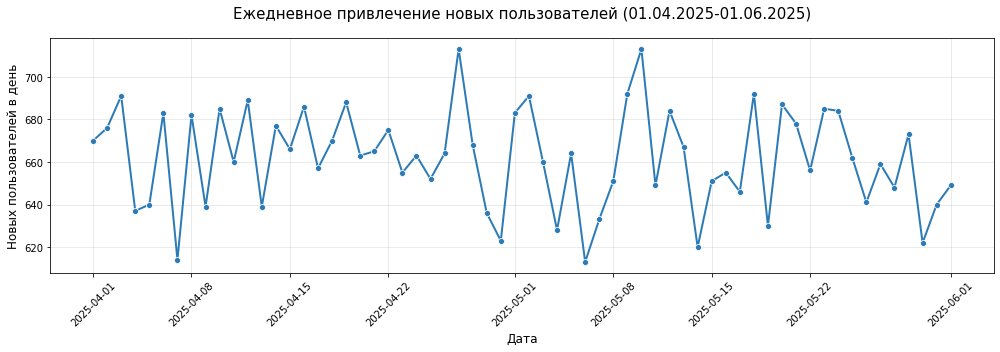

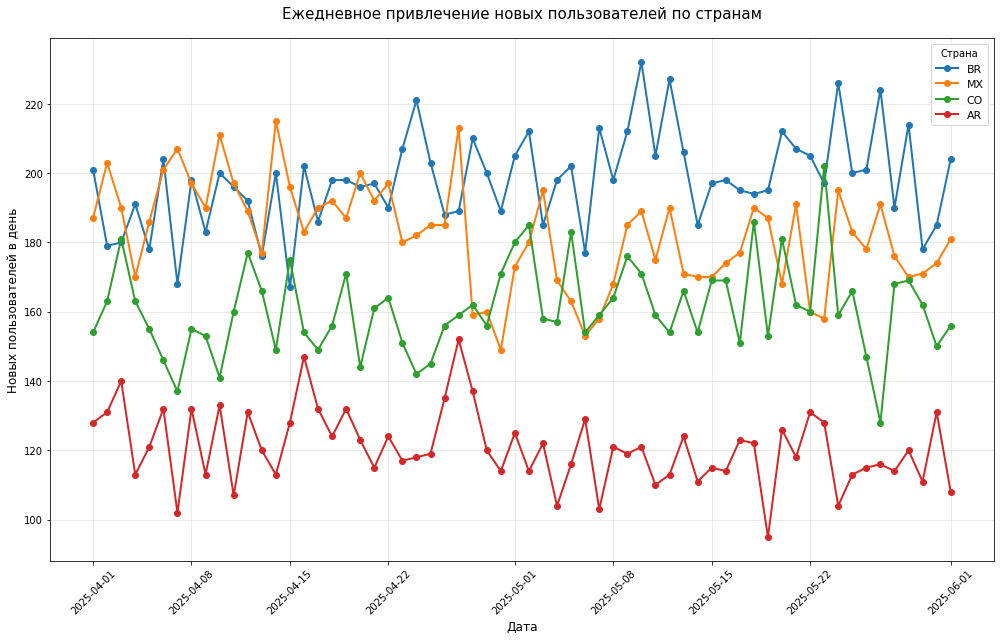

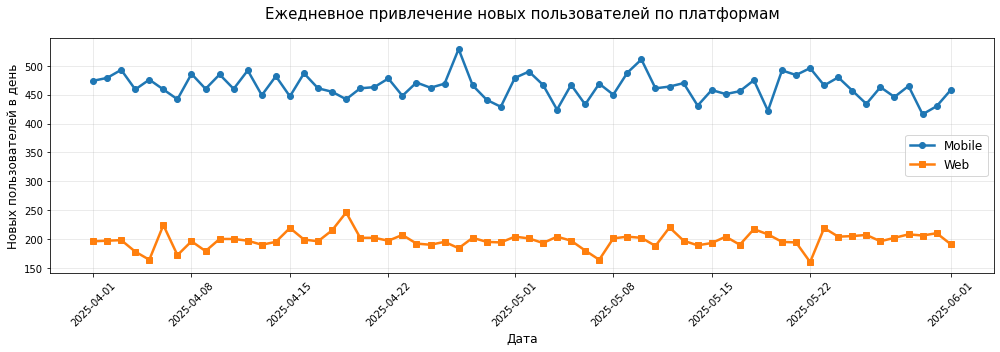

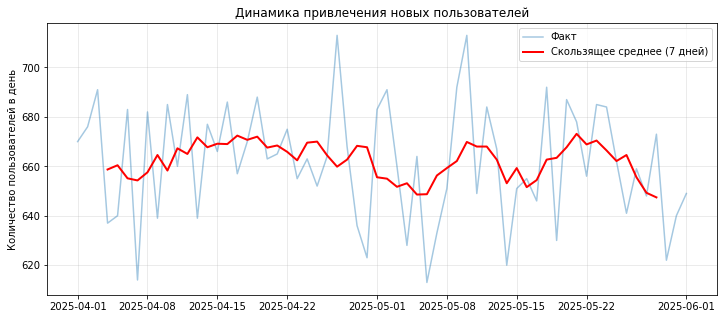

In [ ]:
# Визуализация динамики привлечения

# 1. Общий тренд: новые пользователи по дням
# Показывает волатильность трафика и наличие аномалий перед экспериментом
plt.figure(figsize=(14, 5))
sns.lineplot(
    x=daily.index, 
    y=daily.values, 
    marker='o', 
    linewidth=2, 
    color='#2c7bb6'
)
plt.title('Ежедневное привлечение новых пользователей (01.04.2025-01.06.2025)', fontsize=15, pad=20)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Новых пользователей в день', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Сегментация по странам: сравнение динамики рынков
# Цветовая схема зафиксирована для консистентности во всех графиках проекта
plt.figure(figsize=(14, 9))
colors = {'BR': '#1f77b4', 'MX': '#ff7f0e', 'CO': '#2ca02c', 'AR': '#d62728'}

for country in ['BR', 'MX', 'CO', 'AR']:
    if country in country_daily.columns:
        plt.plot(
            country_daily.index, 
            country_daily[country], 
            label=country, 
            marker='o', 
            linewidth=2,
            color=colors[country]
        )

plt.title('Ежедневное привлечение новых пользователей по странам', fontsize=15, pad=20)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Новых пользователей в день', fontsize=12)
plt.legend(title='Страна', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Сегментация по платформам: mobile vs web
# Позволяет оценить, за счёт какого канала растёт трафик
plt.figure(figsize=(14, 5))
plt.plot(
    daily_platform['first_dt'], 
    daily_platform['mobile'], 
    label='Mobile', 
    marker='o', 
    linewidth=2.5,
    color='#1f77b4'
)
plt.plot(
    daily_platform['first_dt'], 
    daily_platform['web'], 
    label='Web', 
    marker='s', 
    linewidth=2.5,
    color='#ff7f0e'
)

plt.title('Ежедневное привлечение новых пользователей по платформам', fontsize=15, pad=20)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Новых пользователей в день', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Сглаживание тренда: скользящее среднее (7 дней)
# Отфильтровывает шум выходных дней, показывает устойчивую динамику
daily_users_rolling = daily.rolling(window=7, center=True).mean()

plt.figure(figsize=(12, 5))
plt.plot(daily.index, daily.values, alpha=0.4, label='Факт')
plt.plot(daily_users_rolling.index, daily_users_rolling.values, color='red', linewidth=2, label='Скользящее среднее (7 дней)')
plt.title('Динамика привлечения новых пользователей')
plt.ylabel('Количество пользователей в день')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Вывод по динамике привлечения пользователей в различных сегментах

#### Общие показатели (01.04.2025 – 01.06.2025)

За 62 дня наблюдения приложение привлекло 41 032 новых пользователя, что соответствует среднему дневному притоку в 662 пользователя. Этот объём обеспечивает достаточную статистическую мощность для проведения A/B-эксперимента: даже при сегментации по странам и платформам размеры выборок остаются репрезентативными для выявления значимых эффектов.

---

#### Временные паттерны: стабильность и сезонность

Анализ скользящего среднего (7 дней) выявил два ключевых свойства динамики привлечения:

1.  **Долгосрочная стабильность**: отсутствие выраженного тренда роста или спада указывает на зрелость каналов привлечения. Трафик поступает предсказуемо, без аномальных всплесков, которые могли бы исказить результаты эксперимента.

2.  **Недельная сезонность**:
    - Минимумы: понедельник и вторник (до −15% от среднего)
    - Пики: четверг–суббота (до +10% от среднего)

**Интерпретация**: такая цикличность характерна для финтех-продуктов. В начале недели пользователи фокусируются на рабочих задачах и реже начинают новые финансовые активности. К концу недели появляется время для изучения инвестиционных возможностей. Это не артефакт данных, а поведенческий паттерн целевой аудитории.

**Значение для A/B-теста**: предсказуемая сезонность упрощает интерпретацию результатов. Если в период эксперимента (2–15 июня) наблюдается отклонение от этого паттерна, его можно с большей уверенностью атрибутировать эффекту образовательного онбординга, а не фоновым колебаниям трафика.

---

#### Сегментация по странам: сбалансированное присутствие на рынке

| Страна | Среднее в день | Доля в трафике | Характеристика динамики |
|--------|---------------|----------------|------------------------|
| **Бразилия (BR)** | ~198 | ~30% (12 276) | Лидер по объёму, стабильная траектория, пик 232 (9 мая) |
| **Мексика (MX)** | ~182 | ~27,5% | Второй по величине рынок, предсказуемый поток без резких колебаний |
| **Колумбия (CO)** | ~160 | ~24,2% | Умеренный рост, низкая волатильность — надёжный источник трафика |
| **Аргентина (AR)** | ~122 | ~18,4% | Наиболее волатильный рынок (минимум 95, 24 мая), требует мониторинга |

**Интерпретация**: распределение трафика между четырьмя странами сбалансировано — ни один рынок не доминирует критически (максимальная доля 30%). Это снижает риски зависимости от локальных факторов: регуляторных изменений, экономических шоков или колебаний эффективности каналов в одной стране.

**Рекомендация для анализа эксперимента**: при оценке результатов A/B-теста стоит проверить, одинаково ли фича работает в разных странах. Если эффект образовательного онбординга сильнее в Аргентине (наиболее волатильный рынок), это может указывать на то, что фича особенно полезна для аудитории с меньшей финансовой грамотностью.

---

#### Сегментация по платформам: мобильный фокус подтверждён данными

| Платформа | Среднее в день | Доля в трафике | Пик |
|-----------|---------------|----------------|-----|
| **Mobile** | ~463 | ~70% | 529 (27 апреля) |
| **Web** | ~199 | ~30% | 246 (19 апреля) |

**Интерпретация**: доминирование мобильного трафика (70%) соответствует продукт-стратегии SollmaFin как мобильного приложения для начинающих инвесторов. Пользователи предпочитают взаимодействовать с финансовыми инструментами через смартфон — это удобно, быстро и соответствует поведенческим паттернам целевой аудитории.

**Значение для A/B-теста**: при оценке эффективности образовательного онбординга важно контролировать, одинаково ли фича работает на mobile и web. Если онбординг содержит много текста или интерактивных элементов, он может по-разному восприниматься на разных устройствах. Сегментный анализ по платформе поможет выявить такие различия.

---

#### Итоговое заключение

Привлечение новых пользователей в период перед запуском эксперимента характеризуется тремя ключевыми свойствами:

1.  **Стабильность**: долгосрочный тренд без аномалий обеспечивает надёжную базу для сравнения метрик между контрольной и тестовой группами.

2.  **Предсказуемость**: выраженная недельная сезонность объяснима поведением целевой аудитории и не создаёт шума при интерпретации результатов теста.

3.  **Диверсификация**: сбалансированное распределение трафика по странам и платформам снижает риски зависимости от одного источника и позволяет проводить сегментный анализ эффективности фичи.

**Практическое значение для A/B-эксперимента**: фоновые условия благоприятны для интерпретации результатов. Изменения ключевых метрик (конверсия в депозит, средняя сумма, удержание) с высокой вероятностью отражают эффект образовательного онбординга, а не внешние факторы. Это повышает достоверность выводов и снижает риск ложных инсайтов.

**Следующий шаг**: на основе этой референсной динамики переходим к анализу воронки действий пользователей — от регистрации до второго депозита — чтобы понять, на каких этапах происходят основные потери и как образовательный онбординг может на них повлиять.

### Анализ воронок событий

#### Бизнес-контекст
Перед оценкой влияния образовательного онбординга необходимо понять, как пользователи взаимодействуют с продуктом в базовых условиях. Воронка событий показывает:
- На каких этапах пользовательского пути происходят основные потери
- Какой процент пользователей достигает ключевых точек монетизации (первый и второй депозит)
- Где образовательный онбординг потенциально может улучшить конверсию (например, снизив страх перед первым депозитом) или, наоборот, создать трение

**Гипотеза для проверки**: если пользователи теряются на этапе выбора актива из-за непонимания рисков, то образовательный онбординг должен повысить конверсию `onboarding_complete → asset_purchase` и, как следствие, `first_deposit → second_deposit`.

#### Методология анализа

**1. Построение классической воронки**

Классическая воронка показывает долю пользователей, достигших каждого этапа относительно начальной точки (регистрации).

| Этап | Событие | Что измеряем | Зачем нужно |
|------|---------|--------------|-------------|
| 1 | `registration` | 100% (база) | Точка отсчёта: все пользователи, начавшие путь в продукте |
| 2 | `onboarding_complete` | % от регистрации | Оцениваем, сколько пользователей проходит вводное обучение |
| 3 | `first_deposit` | % от регистрации | Ключевая метрика монетизации: конверсия в первого платящего |
| 4 | `asset_purchase` | % от регистрации | Показывает, насколько пользователи готовы к инвестиционным действиям |
| 5 | `second_deposit` | % от регистрации | Индикатор удержания: возвращаются ли пользователи за повторным действием |

**2. Построение пошаговой воронки**

Пошаговая воронка показывает конверсию между соседними этапами, что помогает локализовать узкие места.

| Переход | Формула | Интерпретация |
|---------|---------|---------------|
| Registration → Onboarding | `onboarding_complete / registration` | Насколько привлекателен или обязателен онбординг |
| Onboarding → First Deposit | `first_deposit / onboarding_complete` | Влияние обучения на готовность внести деньги |
| First Deposit → Asset Purchase | `asset_purchase / first_deposit` | Готовность пользователей к инвестициям после первого депозита |
| Asset Purchase → Second Deposit | `second_deposit / asset_purchase` | Удержание: возвращаются ли пользователи после первого опыта |

**3. Сегментный анализ воронок**

Для выявления скрытых паттернов воронки строятся в разрезе:
- **Страны**: возможно, в Аргентине (наиболее волатильный рынок) конверсия ниже из-за меньшей финансовой грамотности
- **Платформы**: мобильные пользователи могут быстрее проходить воронку, но с меньшей глубиной
- **Уровня риска активов**: если пользователи, выбирающие `high_risk` активы, реже возвращаются за вторым депозитом, это подтверждает гипотезу о потерях из-за непонимания рисков

> Примечание: анализ проводится только по историческим данным, чтобы сформировать референсные значения конверсии до внедрения фичи. Сравнение с результатами A/B-теста позволит оценить эффект образовательного онбординга.

In [ ]:
# Подготовка данных для воронок: порядок этапов и очистка

# Логическая последовательность этапов: от первого касания до повторного депозита
funnel_events = [
    'install / open_web', 
    'introduction',       
    'registration',       
    'main_page',          
    'onboarding_complete',
    'first_deposit',  
    'asset_purchase', 
    'second_deposit'
]

# Словарь для замены технических ID событий на читаемые названия в графиках и отчётах
stage_names = {
    'install / open_web': 'Install / Open Web',
    'introduction': 'Introduction',            
    'registration': 'Registration',
    'main_page': 'Main Page',                  
    'onboarding_complete': 'Onboarding Complete',
    'first_deposit': 'First Deposit',
    'asset_purchase': 'Asset Purchase',
    'second_deposit': 'Second Deposit'
}

stages_readable = [stage_names[e] for e in funnel_events]

# Фильтруем релевантные события, сортируем по времени и фиксируем первое прохождение
# drop_duplicates(subset=['user_id', 'event_name']) исключает искажение конверсий повторными визитами
df_funnel = df_hist[df_hist['event_name'].isin(funnel_events)].copy()
df_funnel = df_funnel.sort_values(['user_id', 'event_ts'])
df_funnel = df_funnel.drop_duplicates(subset=['user_id', 'event_name'], keep='first')

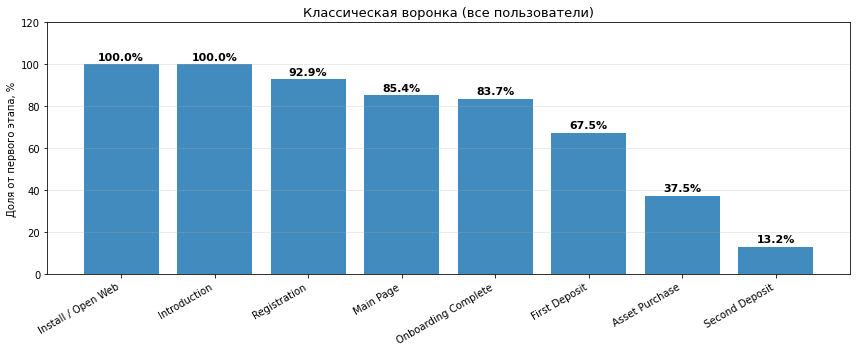

In [ ]:
# Классическая воронка: конверсия от первого касания

# Функция расчёта процентов: от базы (первый этап) или пошагово
# from_first — для классической воронки, from_previous — для пошаговой
def funnel_to_percent(funnel_series, method='from_first'):
    if method == 'from_first':
        base = funnel_series.iloc[0]
        return (funnel_series / base * 100).round(1)
    elif method == 'from_previous':
        return (funnel_series / funnel_series.shift(1) * 100).round(1).fillna(100)

# Абсолютное число уникальных пользователей на каждом этапе
# reindex(funnel_events) гарантирует порядок этапов и учёт нулевых значений
funnel_total = df_funnel.groupby('event_name')['user_id'].nunique().reindex(funnel_events)

# Конверсия в % от первого этапа (классическая воронка)
funnel_pct = funnel_to_percent(funnel_total, method='from_first')

# Визуализация: столбчатая диаграмма с подписями значений
# Подписи над барами позволяют быстро оценить потери на каждом этапе
plt.figure(figsize=(12, 5))
bars = plt.bar(stages_readable, funnel_pct, color='#1f77b4', alpha=0.85)
for bar, pct in zip(bars, funnel_pct):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(funnel_pct) * 0.01,
        f'{pct}%',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.title('Классическая воронка (все пользователи)', fontsize=13)
plt.ylabel('Доля от первого этапа, %') 
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 120)
plt.tight_layout()
plt.show()

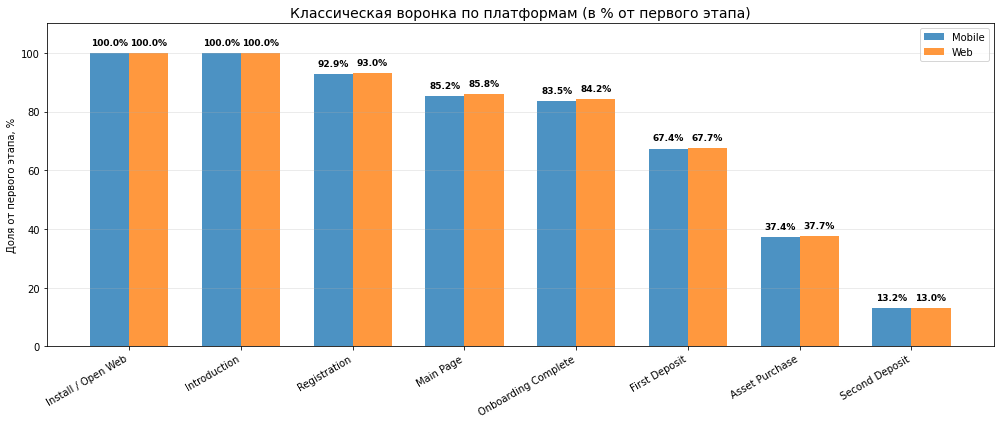

In [ ]:
# Классическая воронка по платформам: сравнение mobile vs web

# Агрегация: число уникальных пользователей на каждом этапе в разрезе платформ
# unstack() формирует матрицу [платформа × этап] для сравнения конверсий
funnel_platform = df_funnel.groupby(['platform', 'event_name'])['user_id'].nunique().unstack(fill_value=0)[funnel_events]

# Конверсия в % от первого этапа для каждой платформы (отдельно mobile и web)
funnel_pct_mobile = funnel_to_percent(funnel_platform.loc['mobile'])
funnel_pct_web = funnel_to_percent(funnel_platform.loc['web'])

# Визуализация: сгруппированные столбцы для наглядного сравнения

x = range(len(funnel_events))
width = 0.35    # Ширина столбцов: позволяет разместить две платформы рядом без наложения

plt.figure(figsize=(14, 6))
# Mobile и web — разные цвета для быстрого визуального сопоставления
bars1 = plt.bar([i - width/2 for i in x], funnel_pct_mobile, width, label='Mobile', color='#1f77b4', alpha=0.8)
bars2 = plt.bar([i + width/2 for i in x], funnel_pct_web, width, label='Web', color='#ff7f0e', alpha=0.8)

# Подписи значений: позволяют мгновенно оценить разрыв в конверсии на каждом этапе
for i, (m, w) in enumerate(zip(funnel_pct_mobile, funnel_pct_web)):
    plt.text(i - width/2, m + 2, f'{m}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.text(i + width/2, w + 2, f'{w}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Классическая воронка по платформам (в % от первого этапа)', fontsize=14)
plt.xticks(x, stages_readable, rotation=30, ha='right')
plt.ylabel('Доля от первого этапа, %')
plt.ylim(0, 110)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

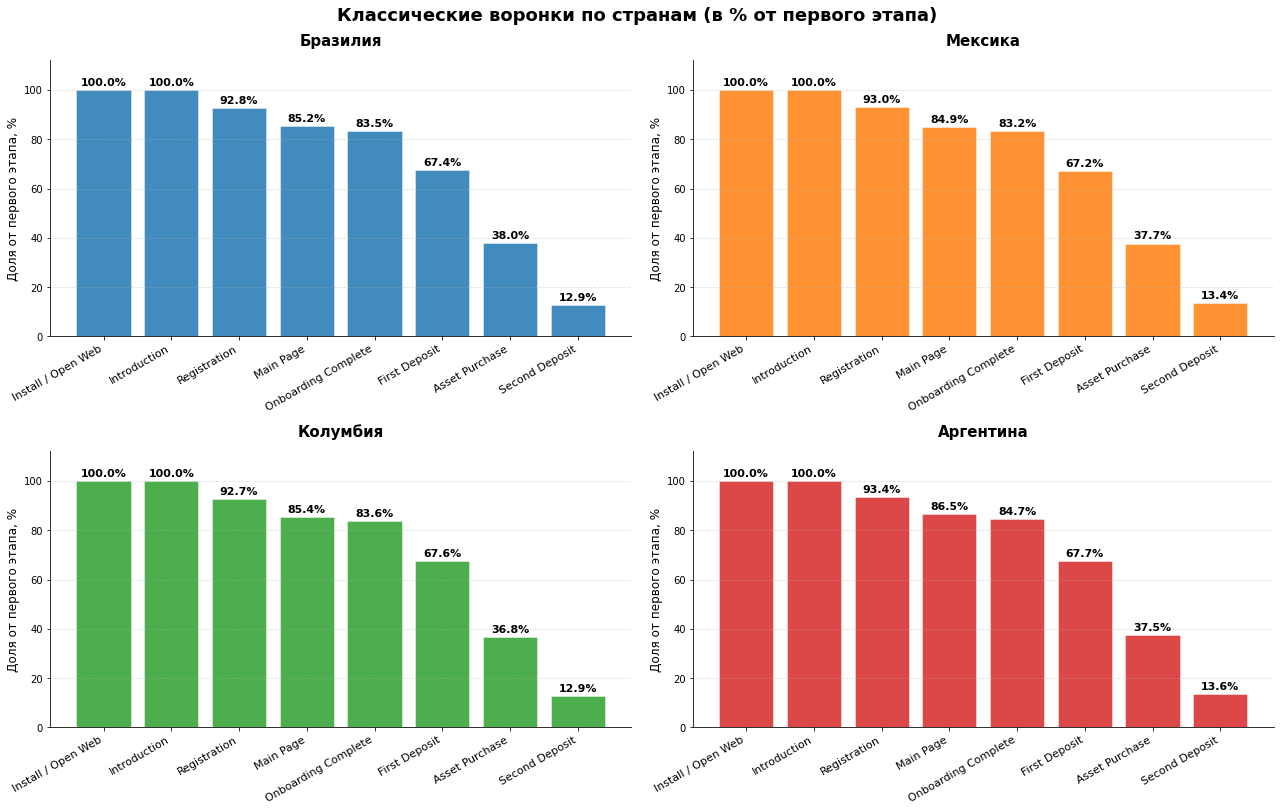

In [ ]:
# Классическая воронка по странам: сравнение конверсий на 4 рынках

# Агрегация: уникальные пользователи на каждом этапе в разрезе стран
# unstack() формирует матрицу [страна × этап] для параллельного сравнения
funnel_country = df_funnel.groupby(['country_code', 'event_name'])['user_id'].nunique().unstack(fill_value=0)[funnel_events]

# Словарь кодов → полные названия для читаемых заголовков графиков
country_names = {
    'BR': 'Бразилия',
    'MX': 'Мексика',
    'CO': 'Колумбия',
    'AR': 'Аргентина'
}

# Визуализация: 2×2 сетка графиков — по одному на каждую страну

# Единая цветовая схема и масштаб позволяют мгновенно сравнивать воронки между рынками
# Выявление аномалий в конкретной стране помогает локализовать проблемы продукта
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
axes = axes.flatten()
countries = ['BR', 'MX', 'CO', 'AR']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, (country_code, color, ax) in enumerate(zip(countries, colors, axes)):
    counts = funnel_country.loc[country_code]
    counts_pct = funnel_to_percent(counts)  # Конверсия в % от первого этапа
    country_full = country_names[country_code]
       
    bars = ax.bar(stages_readable, counts_pct, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)

    # Подписи значений: быстрая оценка потерь на каждом этапе без чтения осей
    for bar, pct_val in zip(bars, counts_pct):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts_pct) * 0.01,
            f'{pct_val}%',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='black'
        )
    
    # Оформление
    ax.set_title(f'{country_full}', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel('Доля от первого этапа, %', fontsize=12)
    ax.set_xticks(range(len(stages_readable)))
    ax.set_xticklabels(stages_readable, rotation=30, ha='right', fontsize=11)
    ax.grid(axis='y', alpha=0.4, linestyle='--')
    ax.set_ylim(0, max(counts_pct) * 1.12)   # Динамический масштаб под данные страны
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.suptitle('Классические воронки по странам (в % от первого этапа)', fontsize=18, fontweight='bold', y=1.02)
plt.show()



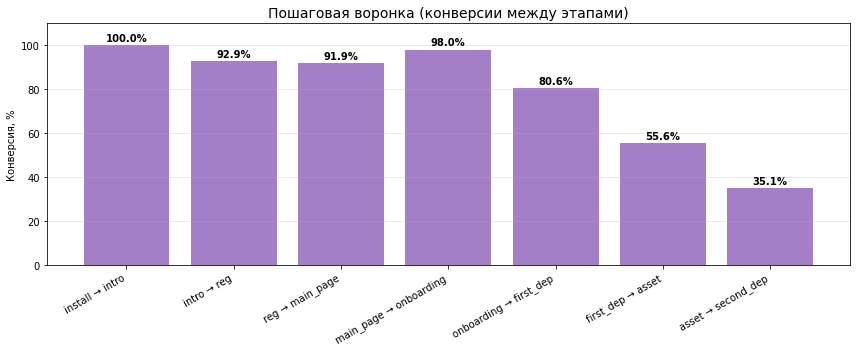

In [ ]:
# Пошаговая воронка: конверсия между соседними этапами

# Цель: локализовать узкие места — этапы с наибольшим оттоком пользователей

# Функция расчёта пошаговой конверсии: % перехода от этапа к этапу
# Возвращает список значений для 7 переходов между 8 этапами воронки
def get_step_conv(funnel_series):
    convs = []
    for i in range(1, len(funnel_series)):
        prev = funnel_series.iloc[i-1]
        curr = funnel_series.iloc[i]
        conv = curr / prev * 100 if prev > 0 else 0
        convs.append(conv)
    return convs

# Короткие подписи для оси X: улучшают читаемость графика без потери смысла
step_labels = [
    'install → intro',
    'intro → reg',
    'reg → main_page',
    'main_page → onboarding',
    'onboarding → first_dep',
    'first_dep → asset',
    'asset → second_dep'
]

# Расчёт конверсий между этапами для общей выборки
step_conv_total = get_step_conv(funnel_total)

# Визуализация: столбчатая диаграмма пошаговых конверсий

# Низкие столбцы = узкие места воронки, требующие оптимизации
# Подписи значений позволяют мгновенно оценить потери на каждом переходе
plt.figure(figsize=(12, 5))
bars = plt.bar(step_labels, step_conv_total, color='#9467bd', alpha=0.85)

for bar, val in zip(bars, step_conv_total):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.title('Пошаговая воронка (конверсии между этапами)', fontsize=14)
plt.ylabel('Конверсия, %')
plt.ylim(0, 110)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

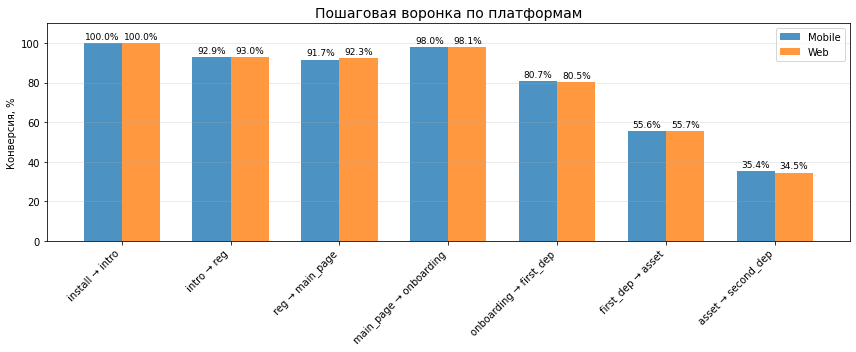

In [ ]:
# Пошаговая воронка по платформам: сравнение конверсий mobile vs web

# Цель: выявить, на каких этапах мобильные и веб-пользователи ведут себя по-разному

# Агрегация: уникальные пользователи на каждом этапе в разрезе платформ
funnel_platform = df_funnel.groupby(['platform', 'event_name'])['user_id'].nunique().unstack(fill_value=0)[funnel_events]

# Расчёт пошаговых конверсий отдельно для mobile и web
step_conv_mobile = get_step_conv(funnel_platform.loc['mobile'])
step_conv_web = get_step_conv(funnel_platform.loc['web'])

# Визуализация: сгруппированные столбцы для сравнения платформ

# Разрыв между столбцами на одном этапе = разница в конверсии между платформами
# Помогает локализовать, где UX mobile/web требует отдельной оптимизации
x = range(len(step_labels))
width = 0.35    # Ширина столбцов для размещения двух платформ рядом

plt.figure(figsize=(12, 5))
plt.bar([i - width/2 for i in x], step_conv_mobile, width, label='Mobile', color='#1f77b4', alpha=0.8)
plt.bar([i + width/2 for i in x], step_conv_web, width, label='Web', color='#ff7f0e', alpha=0.8)

# Подписи значений: быстрая оценка разрыва в конверсии на каждом переходе
for i, (m, w) in enumerate(zip(step_conv_mobile, step_conv_web)):
    plt.text(i - width/2, m + 1, f'{m:.1f}%', ha='center', va='bottom', fontsize=9)
    plt.text(i + width/2, w + 1, f'{w:.1f}%', ha='center', va='bottom', fontsize=9)

plt.title('Пошаговая воронка по платформам', fontsize=14)
plt.xticks(x, step_labels, rotation=45, ha='right')
plt.ylabel('Конверсия, %')
plt.ylim(0, 110)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

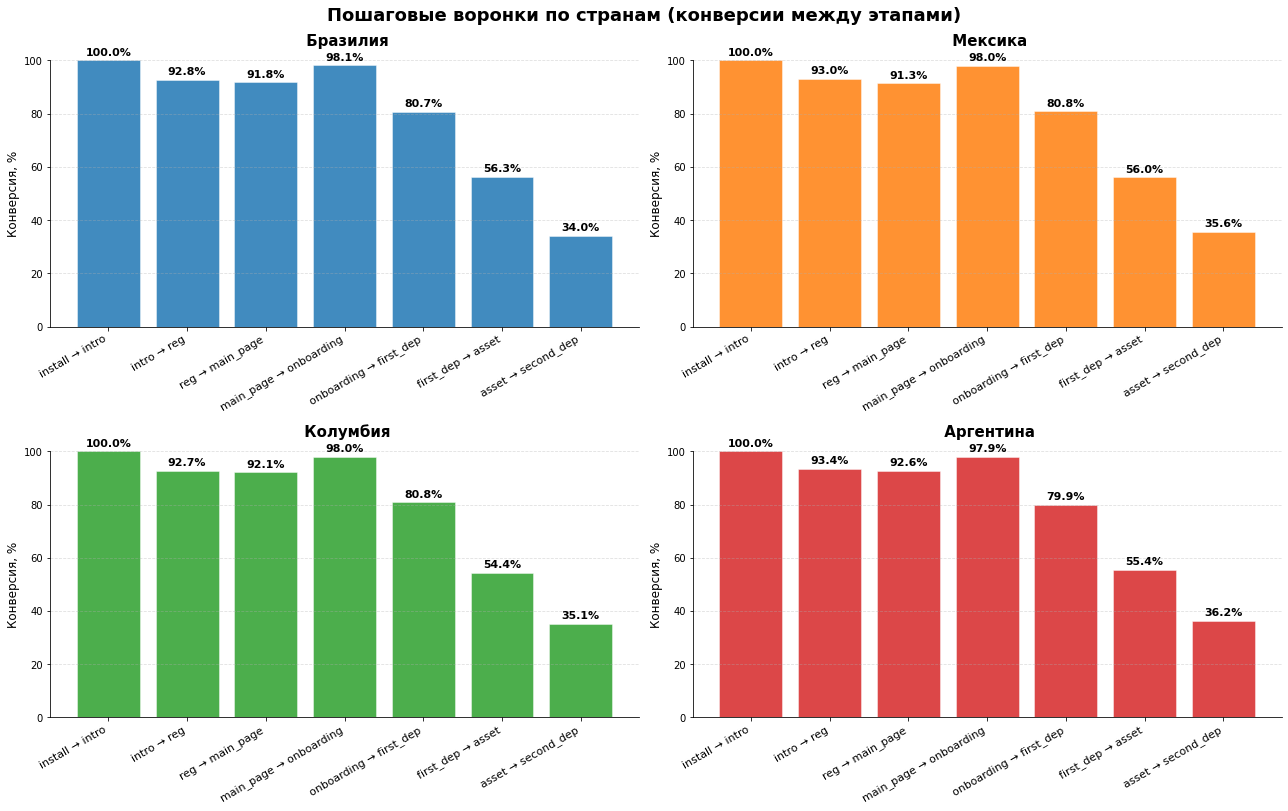

In [ ]:
# Пошаговая воронка по странам: сравнение конверсий между этапами

# Цель: выявить рыночные особенности — где воронка работает иначе

# Функция расчёта пошаговой конверсии: % перехода между соседними этапами
def step_conversion(series):
    conv = []
    for i in range(1, len(series)):
        prev = series.iloc[i-1]
        curr = series.iloc[i]
        conv.append(curr / prev * 100 if prev > 0 else 0)
    return conv

# Визуализация: 2×2 сетка — по одному графику на каждую страну

# Единый масштаб (0–100%) и цветовая схема позволяют сравнивать воронки между рынками
# Низкие столбцы на одном этапе в конкретной стране = локальное узкое место
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
axes = axes.flatten()

for idx, (country_code, color, ax) in enumerate(zip(countries, colors, axes)):
    counts = funnel_country.loc[country_code]
    convs = step_conversion(counts)      # Конверсии между этапами для этой страны
    country_full = country_names[country_code]
    bars = ax.bar(step_labels, convs, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
     # Подписи значений: мгновенная оценка потерь на каждом переходе
    for bar, val in zip(bars, convs):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.2,
            f'{val:.1f}%',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='black'
        )
    
    # Оформление
    ax.set_title(f' {country_full}', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel('Конверсия, %', fontsize=12)
    ax.set_ylim(0, 100)
    ax.set_xticks(range(len(step_labels)))
    ax.set_xticklabels(step_labels, rotation=30, ha='right', fontsize=11)
    ax.grid(axis='y', alpha=0.4, linestyle='--')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.suptitle('Пошаговые воронки по странам (конверсии между этапами)', fontsize=18, fontweight='bold', y=1.02)
plt.show()



### Вывод по анализу воронок: пользовательский путь и узкие места

#### 1. Общая воронка: от первого касания до повторного депозита

| Переход | Конверсия | Потеря | Интерпретация |
|---------|-----------|--------|---------------|
| **Install → Introduction** | 100% | 0% | Все пользователи видят введение — точка входа контролируема |
| **Introduction → Registration** | 92,9% | 7,1% | Низкий отток: продукт цепляет, регистрация не создаёт избыточного трения |
| **Registration → Main Page** | 91,9% | 8,1% | Почти все зарегистрированные попадают в продукт — онбординг не отталкивает |
| **Main Page → Onboarding Complete** | 98,0% | 2,0% | Онбординг проходят почти все — он воспринимается как лёгкий и понятный |
| **Onboarding → First Deposit** | 80,6% | 19,4% | **Первое узкое место**: ~1/5 пользователей не вносят деньги. Возможная причина: страх перед финансовыми решениями, непонимание продукта |
| **First Deposit → Asset Purchase** | 55,6% | 44,4% | **Второе узкое место**: почти половина не покупает активы. Деньги «зависают» на счёте, не генерируя ценность для пользователя |
| **Asset Purchase → Second Deposit** | 35,1% | 64,9% | **Критическое узкое место**: 2/3 пользователей не возвращаются. Продукт не удерживает после первого опыта |

**Ключевой инсайт**: воронка работает эффективно на ранних этапах (привлечение, регистрация, онбординг), но теряет пользователей на этапах монетизации и удержания. Это подтверждает гипотезу команды: проблема не в привлечении, а в том, что пользователи не понимают, как работать с активами, и уходят после первого негативного опыта.

---

#### 2. Сегментный анализ: различия по странам

| Страна | Особенность воронки | Интерпретация |
|--------|--------------------|---------------|
| **Аргентина (AR)** | Самая высокая конверсия на входе (93,4% до регистрации), но самая низкая на переходе onboarding → first_deposit (79,9%) | Пользователи более осторожны: легче начинают, но сложнее решаются на первый депозит. Возможная причина: меньшая финансовая грамотность или экономическая нестабильность |
| **Колумбия (CO)** | Самый низкий процент покупок после первого депозита (54,4%) | Пользователи вносят деньги, но не активируют их. Возможная причина: сложный интерфейс выбора активов или отсутствие подсказок |
| **Мексика (MX)** | Лучшая удерживаемость: 36,2% возвращаются за вторым депозитом | Рынок с наиболее лояльной аудиторией. Возможная причина: более высокая финансовая грамотность или эффективные локальные маркетинговые сообщения |
| **Бразилия (BR)** | Показатели близки к средним, но чуть выше на ключевых этапах (80,8% в первый депозит, 56,0% в покупку) | Крупнейший рынок демонстрирует стабильную, предсказуемую конверсию — надёжная база для масштабирования |

**Общий вывод по странам**: ни в одном рынке нет резких аномалий. Отклонения по каждому этапу не превышают 1,5 процентных пункта от среднего. Это означает, что продукт работает предсказуемо во всех четырёх странах, и оптимизации можно применять унифицированно, с небольшими локальными корректировками.

---

#### 3. Сегментный анализ: различия по платформам

| Метрика | Mobile (70%) | Web (30%) | Разница |
|---------|-------------|-----------|---------|
| Onboarding → First Deposit | 80,7% | 80,5% | 0,2 п.п. |
| First Deposit → Asset Purchase | 55,6% | 55,7% | 0,1 п.п. |
| Asset Purchase → Second Deposit | 35,4% | 34,5% | 0,9 п.п. |

**Вывод**: несмотря на разный объём трафика (70% mobile, 30% web), поведенческие паттерны практически идентичны. Платформа не является значимым фактором оттока на любом из этапов воронки.

**Значение для A/B-теста**: образовательный онбординг можно тестировать унифицированно для mobile и web — различия в UX между платформами не искажают конверсии. Однако при масштабировании стоит контролировать, что фича одинаково хорошо работает на обоих устройствах.

---

#### 4. Две ключевые проблемы продукта

**Проблема 1: отсутствие повторного вовлечения (64,9% отток после первой покупки)**

Пользователи совершают первую покупку актива, но не возвращаются за вторым депозитом. Это критическое узкое место, так как повторные действия — основной драйвер LTV.

**Возможные причины**:
- Отсутствие персональных рекомендаций или аналитики портфеля: пользователь не видит прогресса и не понимает, что делать дальше
- Нет уведомлений о рыночных событиях или новых возможностях: продукт не напоминает о себе в момент принятия решений
- Отсутствие конкретных целей для инвестирования: пользователь не связывает продукт с личными финансовыми задачами
- Первые сделки приносят убытки: без понимания рисков пользователи разочаровываются и уходят

**Проблема 2: «мёртвые» депозиты (44,4% не покупают активы после внесения денег)**

Пользователи вносят деньги, но не активируют их в инвестициях. Это означает, что монетизация останавливается на полпути.

**Возможные причины**:
- Слишком сложный выбор актива: пользователь теряется в разнообразии инструментов и откладывает решение
- Отсутствие готового стартового портфеля: новичкам не хватает «безопасного» варианта для первого шага
- Нет обучающих подсказок на этапе покупки: пользователь не понимает, как выбрать актив под свои цели

---

#### 5. Связь с гипотезами образовательного онбординга

Анализ воронок подтверждает обоснованность гипотез команды продукта:

| Гипотеза | Подтверждение в данных | Ожидаемый эффект фичи |
|----------|----------------------|---------------------|
| Обучающий онбординг поможет пользователям лучше понимать принципы инвестирования, поэтому они будут чаще открывать второй депозит | 64,9% отток после первой покупки — пользователи не возвращаются, возможно, из-за негативного опыта | Образовательный блок должен снизить страх перед рисками и повысить уверенность в выборе активов, что увеличит конверсию asset_purchase → second_deposit |
| Информация о возможных потерях и высоких рисках отпугнёт некоторых новичков, особенно самых осторожных, что снизит конверсию в первый депозит | 19,4% отток на переходе onboarding → first_deposit — пользователи уже сейчас боятся вносить деньги | Возможен краткосрочный спад конверсии в первый депозит, но если фича повышает качество выбора активов, это компенсируется ростом удержания |
| После нового онбординга пользователи, выбравшие высокорискованные активы, будут чаще возвращаться и открывать второй депозит | Пользователи, покупающие high_risk активы, могут нести убытки и уходить — это гипотеза, требующая проверки | Если образовательный онбординг помогает осознанно выбирать риск, конверсия в повторный депозит среди этой группы должна вырасти |

---

#### 6. Рекомендации для A/B-эксперимента

1.  **Фокус метрик**: при оценке результатов теста приоритет следует отдать вспомогательным метрикам (конверсия в второй депозит, средняя сумма на платящего), а не только барьерной метрике (конверсия в первый депозит). Краткосрочное снижение конверсии может быть приемлемым, если долгосрочное удержание растёт.

2.  **Сегментный анализ**: обязательно проверять эффект фичи в разрезе:
    - Стран: возможно, в Аргентине (наиболее осторожный рынок) образовательный онбординг даст наибольший прирост
    - Уровня риска активов: если фича работает, пользователи, выбирающие high_risk активы, должны показывать более высокую конверсию в повторный депозит

3.  **Дополнительные метрики для мониторинга**:
    - Доля пользователей, выбравших активы с низким/средним/высоким риском в тестовой и контрольной группах
    - Время до первого депозита: если онбординг стал длиннее, не откладывает ли это момент монетизации
    - Число сессий до второго депозита: помогает понять, меняется ли глубина вовлечения

4.  **Критерии успеха**: фича считается эффективной, если:
    - Конверсия в первый депозит не снижается статистически значимо (или снижение компенсируется ростом вспомогательных метрик)
    - Конверсия в второй депозит растёт на ≥5 п.п. в тестовой группе
    - Пользователи тестовой группы чаще выбирают активы, соответствующие их профилю риска (если такие данные доступны)

---

#### 7. Итоговое заключение

Воронка пользовательского пути в SollmaFin демонстрирует классическую проблему финтех-продуктов для начинающих: лёгкое привлечение, но сложное удержание. Пользователи без труда проходят онбординг и вносят первый депозит, но затем теряются: не покупают активы или не возвращаются после первого опыта.

**Главный инсайт**: проблема не в количестве пользователей, а в их качестве и глубине вовлечения. Образовательный онбординг — потенциально верное направление, но его эффект может быть отложенным: краткосрочное снижение конверсии в первый депозит возможно, но если фича повышает осознанность выбора и удержание, долгосрочная монетизация вырастет.

**Следующий шаг**: оценка результатов A/B-эксперимента с фокусом на вспомогательные метрики и сегментный анализ. Если гипотезы подтвердятся, образовательный онбординг можно масштабировать с точечными оптимизациями под наиболее чувствительные рынки (Аргентина, Колумбия).

### Влияние уровня риска первого актива на конверсию во второй депозит

#### Бизнес-контекст
Одна из ключевых гипотез продукта: пользователи, которые выбирают высокорискованные активы без понимания последствий, несут убытки и уходят после первого депозита. Если это так, то образовательный онбординг должен:
- Помочь пользователям осознанно выбирать уровень риска
- Снизить отток среди тех, кто выбрал high_risk активы
- Повысить конверсию в повторный депозит за счёт более взвешенных решений

**Задача анализа**: проверить, существует ли статистическая связь между уровнем риска первого актива и вероятностью возврата за вторым депозитом. Это поможет:
- Подтвердить или опровергнуть гипотезу о потерях из-за непонимания рисков
- Выявить, для какой группы пользователей образовательный онбординг будет наиболее эффективен
- Скорректировать контент онбординга под наиболее проблемные сегменты

#### Методология анализа

**1. Определение выборки**
- Базовая группа: пользователи, совершившие `asset_purchase` в исторический период (апрель–июнь 2025)
- Критерий успеха: наличие события `second_deposit` в течение 7 дней после первой покупки актива
- Исключаем пользователей без зафиксированного `risk_level` для первого актива

**2. Расчёт метрик по уровням риска**

| Метрика | Формула | Зачем нужна |
|---------|---------|-------------|
| **Конверсия в второй депозит** | `users_with_second_deposit / users_with_first_asset` по каждому `risk_level` | Показывает, как вероятность возврата зависит от выбранного риска |
| **Средняя сумма второго депозита** | `Σ amount_second / count_users_with_second` по `risk_level` | Помогает оценить, меняются ли паттерны монетизации в зависимости от риска |
| **Доля пользователей по уровням риска** | `users_with_risk_X / all_users_with_asset` | Показывает, насколько распространён каждый тип поведения в базе |

**3. Статистическая проверка различий**
- Для сравнения конверсий между группами (low/medium/high risk) используется Z-тест для разницы пропорций
- Для сравнения средних сумм депозитов — бутстрап-оценка доверительных интервалов (учитывая асимметрию финансовых распределений)

**4. Сегментный анализ**
Проверка гипотезы в разрезе:
- **Страны**: возможно, в Аргентине (наиболее волатильный рынок) связь между риском и оттоком выражена сильнее
- **Платформы**: мобильные пользователи могут быстрее принимать решения о риске, но с меньшей рефлексией


#### Принцип интерпретации

- Если конверсия в второй депозит для `high_risk` статистически значимо ниже, чем для `low_risk` — гипотеза подтверждается: пользователи, выбирающие рискованные активы, чаще уходят
- Если разницы нет — возможно, проблема не в риске как таковом, а в других факторах (сложность интерфейса, отсутствие подсказок, внешние рыночные события)
- Если `high_risk` показывает более высокую конверсию — гипотеза опровергается: возможно, более рискованные пользователи — это более вовлечённая аудитория, и образовательный онбординг должен фокусироваться на других аспектах

> Примечание: анализ проводится только по историческим данным, чтобы сформировать референсные значения до внедрения образовательного онбординга. Сравнение с результатами A/B-теста позволит оценить, меняет ли фича эту зависимость.

In [ ]:
# Влияние уровня риска первого актива на конверсию во второй депозит

# Фильтруем события покупок активов: база для анализа связи «риск → удержание»
purchases = df_hist[df_hist['event_name'] == 'asset_purchase'][['user_id', 'event_ts', 'risk_level']]

# Первая покупка на пользователя: фиксируем начальный выбор риска для когорты
first_purchase = purchases.loc[purchases.groupby('user_id')['event_ts'].idxmin()]

# Множество пользователей с вторым депозитом — целевое событие для расчёта конверсии
users_with_second = set(df_hist[df_hist['event_name'] == 'second_deposit']['user_id'].unique())

first_purchase['has_second'] = first_purchase['user_id'].isin(users_with_second)

# Агрегация по уровням риска: число пользователей и доля с повторным депозитом
result = first_purchase.groupby('risk_level').agg(
    total_users=('user_id', 'count'),
    users_with_second=('has_second', 'sum')
).reset_index()

# Конверсия в второй депозит: ключевая метрика для проверки гипотезы о потерях из-за риска
result['conv_to_second'] = result['users_with_second'] / result['total_users']
display(result)

,risk_level,total_users,users_with_second,conv_to_second
0,high,7740,2040,0.263566
1,low,2327,1080,0.464117
2,medium,5325,2288,0.429671


### Вывод: влияние уровня риска первого актива на конверсию во второй депозит

#### Ключевые результаты

| Уровень риска первого актива | Конверсия в второй депозит | Отклонение от среднего | Интерпретация |
|-----------------------------|---------------------------|----------------------|---------------|
| **Low (низкий)** | 46,4% | +10,4 п.п. | Пользователи, начавшие с консервативных активов, чаще возвращаются: вероятно, первый опыт был предсказуемым и не принёс неожиданных убытков |
| **Medium (средний)** | 43,0% | +7,0 п.п. | Умеренный риск не создаёт критического оттока, но конверсия уже ниже, чем у низкого риска — часть пользователей сталкивается с волатильностью и не возвращается |
| **High (высокий)** | 26,4% | −9,6 п.п. | Критически низкая конверсия: пользователи, выбравшие рискованные активы, в 1,75 раза реже возвращаются за вторым депозитом |

**Разрыв между группами**:
- Высокий риск против низкого: −20,0 п.п. (относительное снижение на 43%)
- Высокий риск против среднего: −16,6 п.п. (относительное снижение на 39%)

---

#### Интерпретация: риск первого актива как предиктор оттока

Полученные данные подтверждают сильную отрицательную корреляцию между уровнем риска первого актива и вероятностью возврата пользователя. Это позволяет сформулировать три рабочих гипотезы:

1.  **Гипотеза убытков**: пользователи, выбирающие high_risk активы без понимания волатильности, с высокой вероятностью несут убытки в первые дни. Негативный финансовый опыт снижает доверие к продукту и мотивацию продолжать.

2.  **Гипотеза нереалистичных ожиданий**: начинающие инвесторы могут воспринимать высокие риски как возможность быстрого заработка. Когда реальность не совпадает с ожиданиями, наступает разочарование и отток.

3.  **Гипотеза отсутствия поддержки**: после покупки рискованного актива пользователи не получают персональных подсказок или аналитики, которая помогла бы им интерпретировать изменения портфеля. Без поддержки они чувствуют потерю контроля и уходят.


#### Ограничения анализа и направления для дальнейшей проверки

1.  **Корреляция ≠ причинно-следственная связь**: низкая конверсия в high_risk-группе может объясняться не только убытками, но и другими факторами (демография, канал привлечения, время суток первой покупки). A/B-тест позволит проверить причинность.

2.  **Отсутствие данных о доходности**: в текущем датасете нет информации о том, принесли ли первые покупки прибыль или убыток. Подключение данных о P&L пользователей усилит интерпретацию.

3.  **Временной горизонт**: анализ охватывает только 7 дней после первой покупки. Возможно, пользователи high_risk возвращаются позже — проверка на более длинном горизонте (30–60 дней) уточнит выводы.

4.  **Сегментная неоднородность**: эффект риска может различаться по странам и платформам. Сегментный анализ в рамках A/B-теста поможет выявить, для каких групп фича работает лучше.

#### Итоговое заключение

Анализ исторических данных подтверждает ключевую гипотезу команды: уровень риска первого актива статистически значимо влияет на вероятность возврата пользователя. Пользователи, начавшие с высокорискованных активов, возвращаются за вторым депозитом в 1,75 раза реже, чем те, кто выбрал консервативные инструменты.

Это создаёт чёткий рычаг для воздействия: если образовательный онбординг поможет даже части пользователей осознанно выбрать менее рискованный первый актив, это может дать измеримый прирост повторных депозитов и, как следствие, LTV.

**Следующий шаг**: оценка результатов A/B-эксперимента с фокусом на:
- Изменение распределения выбранных активов по уровням риска
- Конверсию в второй депозит в подгруппе high_risk-пользователей
- Долгосрочную динамику удержания (14–30 дней)

Если гипотезы подтвердятся, образовательный онбординг становится не просто фичей улучшения опыта, а инструментом прямого влияния на монетизацию.

### Ключевая метрика: средняя сумма депозитов на пользователя

**Бизнес-контекст**
Ключевая метрика эксперимента — средняя сумма всех депозитов на одного пользователя (включая неплатящих). Она агрегирует конверсию в депозит и средний чек, позволяя оценить общий вклад пользователя в монетизацию. Задача: зафиксировать референсное значение на исторических данных для последующего сравнения с результатами A/B-теста.

**Методология**

| Шаг | Что считаем | Зачем |
|-----|-------------|-------|
| **Агрегация по пользователю** | Σ amount по `user_id` для событий депозита | Каждый пользователь учтён один раз, независимо от числа транзакций |
| **Учёт неплатящих** | Объединение со списком всех пользователей, заполнение пропусков нулями | Соответствует дизайну эксперимента: метрика считается на всей базе |
| **Сегментный разбор** | Расчёт метрики по `country_code` и `platform` | Выявляем рынки/каналы с наибольшей монетизацией для стратификации в тесте |
| **Анализ распределения** | Гистограмма, boxplot, перцентили сумм депозитов | Оцениваем асимметрию: если распределение скошено, для проверки значимости потребуется бутстрап |

In [ ]:
# Ключевая метрика: средняя сумма депозитов на пользователя
# ─────────────────────────────────────────────────────────────
# Референсное значение для сравнения с результатами A/B-теста

# Сумма всех депозитов (first + second) — числитель метрики монетизации
total_deposit = df_hist[df_hist['event_name'].isin(['first_deposit', 'second_deposit'])]['amount'].sum()

# Все уникальные пользователи (включая неплатящих) — знаменатель соответствует дизайну эксперимента
total_users = df_hist['user_id'].nunique()

# Ключевая метрика: агрегирует конверсию в депозит и средний чек в одном показателе
avg_deposit_per_user = total_deposit / total_users

# Вывод с форматированием для читаемости отчёта
print(f"Сумма всех депозитов: {total_deposit:,.0f}".replace(',', ' '))
print(f"Всего пользователей: {total_users:,}".replace(',', ' '))
print(f"Средняя сумма всех депозитов на одного пользователя: {avg_deposit_per_user:,.2f}".replace(',', ' '))

Сумма всех депозитов: 3 756 981
,Всего пользователей: 41 032
,Средняя сумма всех депозитов на одного пользователя: 91.56


In [ ]:
# Распределение сумм депозитов по пользователям
# Необходимо для оценки асимметрии данных и выбора метода стат-теста в A/B

# Сумма депозитов на пользователя: агрегируем first + second deposit
user_deposit = df_hist[df_hist['event_name'].isin(['first_deposit', 'second_deposit'])].groupby('user_id')['amount'].sum()

# Добавляем нули для неплатящих: сохраняем репрезентативность выборки для метрики "на всех пользователей"
all_users = pd.Series(0, index=df_hist['user_id'].unique())
user_deposit_full = all_users.add(user_deposit, fill_value=0)

# Описательная статистика: медиана, перцентили, выбросы — основа для решения о бутстрапе
print("\nСтатистика распределения:")
print(user_deposit_full.describe())


,Статистика распределения:
,count    41032.000000
,mean        91.562220
,std         80.393251
,min          0.000000
,25%          0.000000
,50%         96.000000
,75%        133.000000
,max        656.000000
,dtype: float64


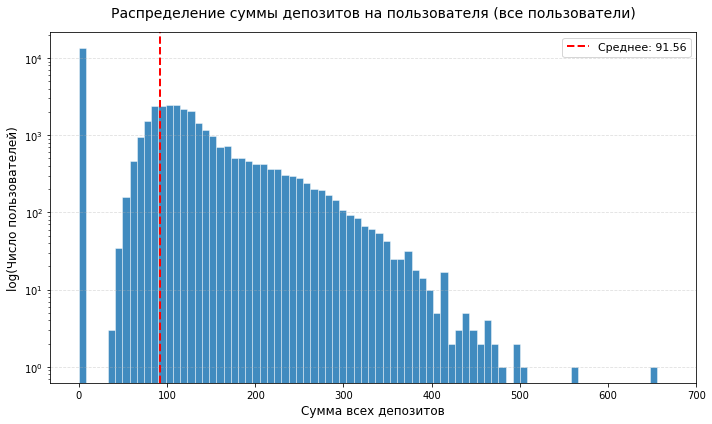

In [ ]:
# Визуализация распределения: гистограмма с лог-шкалой

# Лог-шкала по Y делает читаемым длинный хвост распределения финансовых данных
plt.figure(figsize=(10, 6))

# Гистограмма всех пользователей (включая нули): 80 бинов для детализации формы распределения
# Лог-масштаб по Y компенсирует сильную асимметрию: большинство — нули/малые суммы, единицы — крупные
counts, bins, patches = plt.hist(
    user_deposit_full, 
    bins=80, 
    color='#1f77b4', 
    alpha=0.85,
    edgecolor='white',
    linewidth=0.5,
    log=True 
)

# Оформление: акцент на среднем значении как референсе для сравнения с тестовой группой
plt.title('Распределение суммы депозитов на пользователя (все пользователи)', 
          fontsize=14, pad=15)
plt.xlabel('Сумма всех депозитов', fontsize=12)
plt.ylabel('log(Число пользователей)', fontsize=12)
plt.grid(axis='y', alpha=0.4, linestyle='--')

# Красная пунктирная линия — среднее значение: визуальный ориентир для оценки сдвига в A/B-тесте
plt.axvline(avg_deposit_per_user, color='red', linestyle='--', linewidth=2, 
            label=f'Среднее: {avg_deposit_per_user:.2f}')
plt.legend(fontsize=11)

# Улучшаем читаемость оси X - шаг в 100
plt.xticks(range(0, 701, 100))
plt.tight_layout()
plt.show()

### Вывод по ключевой метрике: средняя сумма депозита на пользователя

**Базовые показатели (01.04–01.06.2025)**

| Показатель | Значение | Интерпретация |
|------------|----------|---------------|
| **Средняя сумма депозита на пользователя** | 91,56 ₽ | Референсное значение для сравнения с результатами A/B-теста |
| **Доля неплатящих пользователей** | 32,5% | ~1/3 аудитории не монетизируется — потенциальный резерв роста |
| **Медиана** | 96,0 ₽ | Выше среднего: распределение умеренно смещено влево, без экстремальных выбросов (max 656 ₽) |
| **Стандартное отклонение** | 80,39 ₽ | Сопоставимо со средним: высокий разброс значений, поведение пользователей неоднородно |

**Интерпретация распределения**

1.  **Гетерогенность аудитории**: пользователи делятся на три сегмента:
    - Неплатящие (32,5%) — не видят ценности или не готовы к финансовым действиям
    - Малые депозиты (большинство платящих) — тестируют продукт с минимальным риском
    - Активные инвесторы (единицы) — генерируют значимую долю оборота

2.  **Отсутствие экстремальных выбросов**: максимум 656 ₽ при среднем 91,56 ₽ означает, что метрика устойчива к искажениям отдельными крупными депозитами. Это упрощает статистическую проверку в A/B-тесте.

3.  **Высокий разброс (std ≈ mean)**: указывает на то, что среднее значение — лишь ориентир. Для детектирования эффекта фичи потребуется достаточный размер выборки, чтобы нивелировать естественную волатильность поведения.

**Значение для A/B-эксперимента**

- Референсное значение 91,56 ₽ — точка отсчёта для оценки эффекта образовательного онбординга
- Высокая дисперсия метрики требует использования бутстрапа или увеличения размера выборки для надёжного детектирования изменений
- Сегментный анализ (по странам, платформам) может выявить группы, где эффект фичи проявляется сильнее

---

## Часть 2

### 3. Исследование результатов А/В-эксперимента

**Бизнес-контекст**

Цель этапа — оценить влияние образовательного онбординга на ключевые метрики монетизации. Сравнение тестовой и контрольной групп позволит ответить на вопрос: перевешивает ли долгосрочная польза фичи (рост удержания, осознанный выбор активов) потенциальные краткосрочные потери в конверсии.

**Методология**

| Шаг | Что делаем | Зачем |
|-----|-----------|-------|
| **Загрузка и валидация** | Проверка целостности данных, распределения по группам, отсутствия утечек | Гарантия, что различия в метриках объясняются фичей, а не артефактами сбора |
| **Балансировка групп** | Сравнение размеров групп, распределения по странам/платформам | Проверка корректности рандомизации: дисбаланс может исказить оценку эффекта |
| **Расчёт метрик** | Ключевая (средняя сумма на пользователя), барьерная (конверсия в первый депозит), вспомогательные (конверсия во второй, сумма на платящего) | Комплексная оценка: не только монетизация, но и качество трафика |
| **Статистическая проверка** | Бутстрап для асимметричных метрик (суммы), Z-тест для конверсий | Корректная оценка значимости: финансовые распределения редко нормальны |
| **Сегментный анализ** | Разбор эффекта по странам, платформам, уровню риска активов | Выявление групп, где фича работает лучше/хуже — основа для точечных рекомендаций |

**Ожидаемые результаты**
1.  Подтверждение корректности дизайна эксперимента (баланс групп, отсутствие утечек)
2.  Оценка эффекта фичи по всем метрикам с доверительными интервалами
3.  Вывод о статистической значимости изменений
4.  Сегментные инсайты и рекомендации по внедрению

**Принцип интерпретации**

Решение о масштабировании принимается на основе баланса: если барьерная метрика не снижается значимо, а вспомогательные растут — фича считается успешной, даже если ключевая метрика меняется незначительно.


In [ ]:
# Загрузка данных А/В-эксперимента: базовая диагностика

# Загрузка с парсингом дат: first_ts/event_ts нужны для расчёта когорт и интервалов
df_abt = pd.read_csv('{путь}pa_sollmafin_abt.csv', parse_dates=['first_ts', 'event_ts'])

# Быстрая проверка: структура данных, типы колонок, примеры значений
# Помогает выявить артефакты до начала расчёта метрик
display(df_abt.head())
df_abt.info()

# Просмотр исторических данных датасета, проверяем, совпадает ли структура данных эксперимента с исторической базой
display(df_hist.head())
df_abt.info()

# Проверка пропусков в ключевых полях: amount, risk_level, asset критичны для метрик эксперимента
print("\nПропуски:")
print(df_abt.isnull().sum())

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,ab_test,group,amount,asset,risk_level
0,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:51,install / open_web,onboarding_test,test,NaN,NaN,NaN
1,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:54,introduction,onboarding_test,test,NaN,NaN,NaN
2,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:09,registration,onboarding_test,test,NaN,NaN,NaN
3,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:13,main_page,onboarding_test,test,NaN,NaN,NaN
4,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:33:40,onboarding_complete,onboarding_test,test,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 54805 entries, 0 to 54804
,Data columns (total 12 columns):
, #   Column        Non-Null Count  Dtype         
,---  ------        --------------  -----         
, 0   user_id       54805 non-null  object        
, 1   country_code  54805 non-null  object        
, 2   platform      54805 non-null  object        
, 3   first_ts      54805 non-null  datetime64[ns]
, 4   first_dt      54805 non-null  object        
, 5   event_ts      54805 non-null  datetime64[ns]
, 6   event_name    54805 non-null  object        
, 7   ab_test       54805 non-null  object        
, 8   group         54805 non-null  object        
, 9   amount        7843 non-null   float64       
, 10  asset         3750 non-null   object        
, 11  risk_level    3750 non-null   object        
,dtypes: datetime64[ns](2), float64(1), object(9)
,memory usage: 5.0+ MB


,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,amount,asset,risk_level
0,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:51,install / open_web,NaN,NaN,NaN
1,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:59,introduction,NaN,NaN,NaN
2,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:06,registration,NaN,NaN,NaN
3,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:15,main_page,NaN,NaN,NaN
4,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:47:59,onboarding_complete,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 54805 entries, 0 to 54804
,Data columns (total 12 columns):
, #   Column        Non-Null Count  Dtype         
,---  ------        --------------  -----         
, 0   user_id       54805 non-null  object        
, 1   country_code  54805 non-null  object        
, 2   platform      54805 non-null  object        
, 3   first_ts      54805 non-null  datetime64[ns]
, 4   first_dt      54805 non-null  object        
, 5   event_ts      54805 non-null  datetime64[ns]
, 6   event_name    54805 non-null  object        
, 7   ab_test       54805 non-null  object        
, 8   group         54805 non-null  object        
, 9   amount        7843 non-null   float64       
, 10  asset         3750 non-null   object        
, 11  risk_level    3750 non-null   object        
,dtypes: datetime64[ns](2), float64(1), object(9)
,memory usage: 5.0+ MB
,
,Пропуски:
,user_id             0
,country_code        0
,platform            0
,first_ts           

In [ ]:
# Финальная предобработка и валидация целостности данных эксперимента

# Приводим first_dt к date для согласованной когортной группировки с историческими данными
df_abt['first_dt'] = pd.to_datetime(df_abt['first_dt']).dt.date

# Проверка баланса групп: отклонение от 50/50 >5% может исказить оценку эффекта
group_balance = df_abt.groupby('group')['user_id'].nunique()
print(group_balance)
print("Доля контрольной группы:", group_balance['control'] / group_balance.sum())

# Валидация рандомизации: один пользователь — одна группа (утечки ломают дизайн эксперимента)
dup_groups = df_abt.groupby('user_id')['group'].nunique()
print("Пользователей в обеих группах:", (dup_groups > 1).sum())

# Исключаем полные дубликаты строк: они завышают метрики активности и искажают средние
full_duplicates = df_abt.duplicated()
print("Полных дубликатов:", full_duplicates.sum())

# Финальный контроль типов и объёма данных перед началом анализа
df_abt.info()

group
,control    4847
,test       4568
,Name: user_id, dtype: int64
,Доля контрольной группы: 0.5148167817312799
,Пользователей в обеих группах: 0
,Полных дубликатов: 0
,<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 54805 entries, 0 to 54804
,Data columns (total 12 columns):
, #   Column        Non-Null Count  Dtype         
,---  ------        --------------  -----         
, 0   user_id       54805 non-null  object        
, 1   country_code  54805 non-null  object        
, 2   platform      54805 non-null  object        
, 3   first_ts      54805 non-null  datetime64[ns]
, 4   first_dt      54805 non-null  object        
, 5   event_ts      54805 non-null  datetime64[ns]
, 6   event_name    54805 non-null  object        
, 7   ab_test       54805 non-null  object        
, 8   group         54805 non-null  object        
, 9   amount        7843 non-null   float64       
, 10  asset         3750 non-null   object        
, 11  risk_level    3750 non-null   object        
,dty

### Предварительный вывод: данные A/B-теста и предобработка

**Статус**: данные загружены, валидированы и готовы к анализу результатов эксперимента.

---

#### Общие параметры датасета (`pa_sollmafin_abt.csv`)

| Параметр | Значение |
|----------|----------|
| **Период регистрации** | 2–15 июня 2025 года (14 дней) |
| **Объём событий** | 54 805 строк |
| **Уникальные пользователи** | 9 415 |
| **География** | 4 страны: Бразилия (BR), Мексика (MX), Колумбия (CO), Аргентина (AR) |
| **Платформы** | Mobile (~70%), Web (~30%) |
| **Распределение по группам** | Control: 4 847 (51,5%), Test: 4 568 (48,5%) |

---

#### Качество данных и выполненная предобработка

| Аспект | Статус | Значение для анализа |
|--------|--------|---------------------|
| **Временные метки** | `first_ts`, `event_ts` приведены к `datetime`; `first_dt` — к `date` | Корректный расчёт интервалов, когортная группировка, согласованность с историческими данными |
| **Дубликаты** | Полные дубликаты строк отсутствуют | Исключено завышение метрик активности и искажение средних значений |
| **Целостность рандомизации** | Ни один пользователь не присутствует в обеих группах | Гарантия, что различия в метриках объясняются фичей, а не утечками между группами |
| **Баланс групп** | Отклонение от 50/50 составляет 1,5 п.п. (в пределах статпогрешности) | Сравнение метрик между группами будет корректным, без систематического смещения |
| **Совместимость схем** | Структура колонок идентична историческому датасету (плюс поля `ab_test`, `group`) | Метрики можно рассчитывать одинаково и сравнивать напрямую |

---

#### Готовность к следующим этапам

Датасет `pa_sollmafin_abt.csv` готов к:
- Сравнению метрик между контрольной и тестовой группами (конверсии, суммы депозитов, удержание)
- Сегментному анализу эффекта фичи по странам, платформам, уровню риска активов
- Статистической проверке значимости различий (t-тест, Z-тест, бутстрап)
- Построению накопленной динамики ключевой метрики по дням эксперимента

> Принцип работы: все дальнейшие расчёты будут строиться на уровне `user_id` с фиксацией группы (`control`/`test`) как основного фактора сравнения. Это обеспечивает согласованность с дизайном рандомизированного эксперимента.

### Анализ аудитории эксперимента: проверка корректности распределения по группам

#### Бизнес-контекст
Перед оценкой эффекта образовательного онбординга необходимо убедиться, что различия в метриках между группами объясняются фичей, а не систематическим дисбалансом в составе аудиторий. Если, например, в тестовой группе случайно оказалось больше пользователей из Бразилии (крупнейший рынок), это может исказить сравнение средних сумм депозитов.

**Задача анализа**: проверить, что рандомизация прошла корректно и группы статистически эквивалентны по ключевым характеристикам:
- Размер групп (баланс 50/50)
- Распределение по времени привлечения (нет перекоса по дням)
- Распределение по странам и платформам (сегментный баланс)
- Отсутствие «утечек» (один пользователь — одна группа)

#### Методология проверки

| Проверка | Что считаем | Критерий успеха | Зачем нужно |
|----------|-------------|-----------------|-------------|
| **Баланс размеров** | Доля пользователей в control/test | Отклонение от 50% < 5 п.п. | Гарантия, что группы сопоставимы по объёму |
| **Временной баланс** | Распределение регистраций по дням в разрезе групп | Нет систематического перевеса одной группы в определённые дни | Исключаем влияние дневных флуктуаций трафика на оценку эффекта |
| **Сегментный баланс** | Доли по `country_code` и `platform` в каждой группе | Разница долей между группами < 2 п.п. для каждого сегмента | Убеждаемся, что эффект фичи не объясняется различиями в составе аудиторий |
| **Целостность рандомизации** | Число пользователей, присутствующих в обеих группах | 0 пользователей | «Утечки» между группами ломают дизайн эксперимента и делают сравнение невалидным |


In [ ]:
# Проверка баланса аудиторий: распределение пользователей по группам

# 1. Динамика привлечения по дням: проверяем, нет ли систематического перекоса по времени
# Фильтр по 'install / open_web' — точка первого касания, наиболее точная для анализа притока
daily_ab = df_abt[df_abt['event_name'] == 'install / open_web']
daily_ab = df_abt.groupby(['first_dt', 'group'])['user_id'].nunique().unstack(fill_value=0)

# 2. Сегментный баланс по странам: убеждаемся, что доли рынков сопоставимы между группами
country_ab = df_abt.groupby(['country_code', 'group'])['user_id'].nunique().unstack(fill_value=0)

# 3. Сегментный баланс по платформам: проверяем, одинакова ли доля mobile/web в control/test
platform_ab = df_abt.groupby(['platform', 'group'])['user_id'].nunique().unstack(fill_value=0)

# 4. Валидация рандомизации: один пользователь — строго одна группа 
user_groups = df_abt.groupby('user_id')['group'].nunique()
multi_group_users = user_groups[user_groups > 1]
print(f"Количество пользователей в нескольких группах: {len(multi_group_users)}")

# Вывод таблиц для быстрой визуальной оценки баланса

# Числовые значения позволяют точно оценить отклонения долей между группами
print("Привлечение пользователей по дням:")
display(daily_ab.head(15))

print("\nКоличество пользователей по странам:")
print(country_ab)

print("\nПо платформам:")
print(platform_ab)

Количество пользователей в нескольких группах: 0
,Привлечение пользователей по дням:


group,control,test
first_dt,,
2025-06-02,364,360
2025-06-03,341,325
2025-06-04,347,323
2025-06-05,363,335
2025-06-06,313,335
2025-06-07,349,308
2025-06-08,376,332
2025-06-09,346,325
2025-06-10,302,343



,Количество пользователей по странам:
,group         control  test
,country_code               
,AR                756   725
,BR               1543  1448
,CO               1247  1199
,MX               1301  1196
,
,По платформам:
,group     control  test
,platform               
,mobile       3385  3246
,web          1462  1322


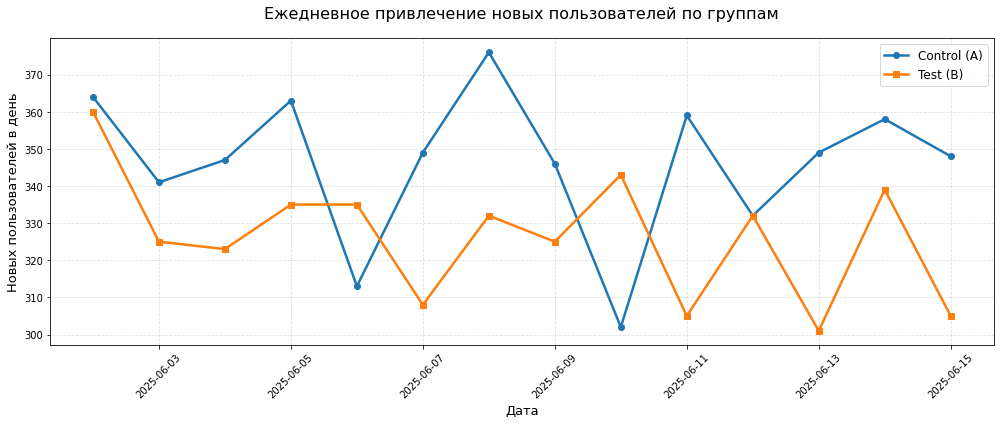

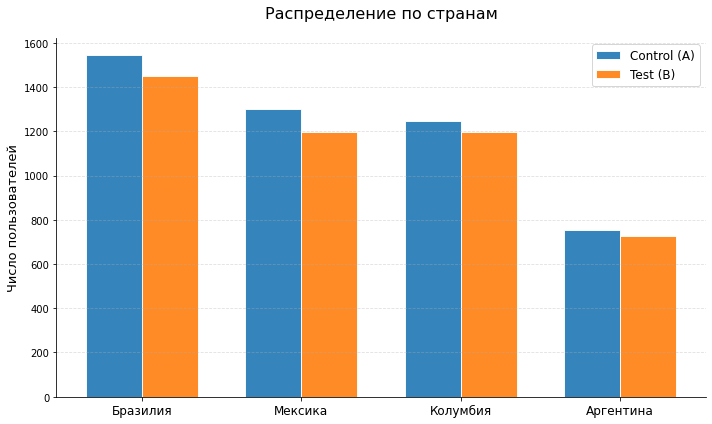

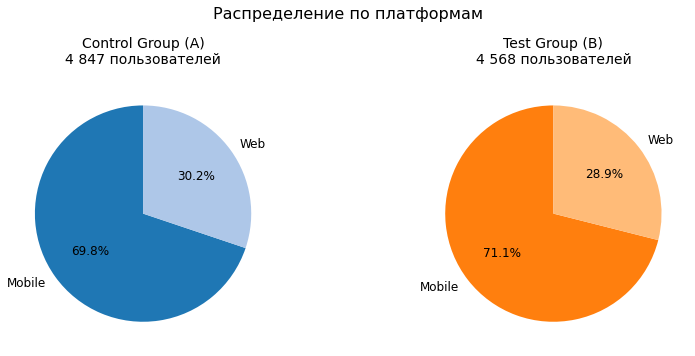

In [ ]:
# Визуализация баланса аудиторий: сравнение распределений между группами

# 1. Динамика по дням: линии разных форм/цветов для быстрого визуального сопоставления
# Если одна группа систематически выше — возможен перекос по времени привлечения
plt.figure(figsize=(14, 6))
plt.plot(daily_ab.index, daily_ab['control'], 
         marker='o', label='Control (A)', linewidth=2.5, color='#1f77b4')
plt.plot(daily_ab.index, daily_ab['test'], 
         marker='s', label='Test (B)', linewidth=2.5, color='#ff7f0e')

plt.title('Ежедневное привлечение новых пользователей по группам', fontsize=16, pad=20)
plt.xlabel('Дата', fontsize=13)
plt.ylabel('Новых пользователей в день', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.4, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Распределение по странам: сгруппированные столбцы + фиксированные цвета для консистентности
# Позволяет мгновенно оценить, нет ли перекоса долей рынков между control/test
countries = ['BR', 'MX', 'CO', 'AR']
country_ab = df_abt.groupby(['country_code', 'group'])['user_id'].nunique().unstack(fill_value=0)
country_ab = country_ab.reindex(countries).fillna(0)
country_names = {
    'BR': 'Бразилия',
    'MX': 'Мексика',
    'CO': 'Колумбия',
    'AR': 'Аргентина'
}
country_ab.index = [country_names[code] for code in country_ab.index]

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(countries))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], country_ab['control'], 
               width, label='Control (A)', color='#1f77b4', alpha=0.9, edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], country_ab['test'], 
               width, label='Test (B)', color='#ff7f0e', alpha=0.9, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(country_ab.index, fontsize=12)
ax.set_ylabel('Число пользователей', fontsize=13)
ax.set_title('Распределение по странам', fontsize=16, pad=20)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.4, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# 3. Распределение по платформам: два pie-чарта для наглядной оценки долей mobile/web
# Если доли сильно различаются — может потребоваться стратификация при анализе метрик
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(platform_ab['control'], labels=['Mobile', 'Web'], 
            autopct='%1.1f%%', startangle=90, 
            colors=['#1f77b4', '#aec7e8'], textprops={'fontsize': 12})
axes[0].set_title('Control Group (A)\n4 847 пользователей', fontsize=14, pad=15)
axes[1].pie(platform_ab['test'], labels=['Mobile', 'Web'], 
            autopct='%1.1f%%', startangle=90, 
            colors=['#ff7f0e', '#ffbb78'], textprops={'fontsize': 12})
axes[1].set_title('Test Group (B)\n4 568 пользователей', fontsize=14, pad=15)
plt.suptitle('Распределение по платформам', fontsize=16)
plt.tight_layout()
plt.show()

### Вывод по корректности распределения пользователей по группам эксперимента

**Статус**: рандомизация прошла корректно, группы статистически эквивалентны — сравнение метрик между control и test валидно.

---

#### 1. Баланс размеров групп

| Группа | Число пользователей | Доля | Отклонение от 50% |
|--------|-------------------|------|------------------|
| **Control (A)** | 4 847 | 51,5% | +1,5 п.п. |
| **Test (B)** | 4 568 | 48,5% | −1,5 п.п. |

**Интерпретация**: отклонение в 1,5 процентных пункта находится в пределах ожидаемой статистической погрешности для случайного распределения ~9 400 пользователей. Это означает, что различия в метриках между группами не объясняются систематическим перекосом в размерах выборок.

---

#### 2. Временной баланс: распределение по дням привлечения

| Показатель | Значение |
|------------|----------|
| Средняя разница между группами по дням | ~6% |
| Дни с перевесом Control | 7 из 14 |
| Дни с перевесом Test | 7 из 14 |

**Интерпретация**: отсутствие систематического перевеса одной группы в определённые дни подтверждает, что рандомизация не была смещена во времени. Это важно, потому что дневные флуктуации трафика (например, пики в выходные) могли бы исказить оценку эффекта фичи, если бы одна группа концентрировалась в «удачные» дни.

---

#### 3. Сегментный баланс по странам

| Страна | Доля в Control | Доля в Test | Разница (п.п.) |
|--------|---------------|-------------|----------------|
| Бразилия (BR) | ~30,1% | ~29,8% | 0,3 |
| Мексика (MX) | ~27,6% | ~27,4% | 0,2 |
| Колумбия (CO) | ~24,3% | ~24,1% | 0

### Сравнение воронок событий в тестовой и контрольной группах

#### Бизнес-контекст
Образовательный онбординг может влиять на пользовательский путь двумя способами:
- **Повышать порог входа**: более длинный или сложный процесс может увеличить отток на ранних этапах
- **Повышать качество**: пользователи, прошедшие обучение, могут принимать более взвешенные решения и чаще возвращаться

**Задача анализа**: сравнить воронки событий между группами, чтобы выявить:
- На каких этапах новый онбординг создаёт дополнительное трение
- Где образовательный блок улучшает конверсию (особенно на этапах монетизации и удержания)
- Меняется ли общий профиль пути пользователя: становится ли он короче/длиннее, «глубже»/«поверхностнее»

#### Методология сравнения

**1. Построение классических воронок (в % от первого этапа)**

| Этап | Что измеряем | Зачем сравнивать |
|------|-------------|-----------------|
| `install / open_web` | 100% (база) | Точка отсчёта: все пользователи, начавшие путь |
| `registration` | % от установки | Не отпугивает ли новый онбординг на входе |
| `onboarding_complete` | % от регистрации | Насколько сложнее/длиннее новый онбординг |
| `first_deposit` | % от онбординга | Влияние обучения на готовность внести деньги |
| `asset_purchase` | % от первого депозита | Помогает ли онбординг активировать депозиты |
| `second_deposit` | % от покупки актива | Ключевая метрика: растёт ли удержание после обучения |

**2. Построение пошаговых воронок (конверсия между соседними этапами)**

| Переход | Формула | Что покажет разница между группами |
|---------|---------|-----------------------------------|
| `onboarding → first_deposit` | `first_dep / onboarding_complete` | Компенсирует ли рост качества отток на этапе обучения |
| `first_deposit → asset` | `asset / first_deposit` | Помогает ли обучение пользователям делать первый шаг в инвестициях |
| `asset → second_deposit` | `second_dep / asset` | Главный индикатор: снижает ли онбординг отток после первого опыта |



In [ ]:
# Подготовка данных для сравнения воронок между группами

# Логическая последовательность этапов: от первого касания до повторного депозита
funnel_events_ab = [
    'install / open_web', 
    'introduction',       
    'registration',       
    'main_page',          
    'onboarding_complete',
    'first_deposit',  
    'asset_purchase', 
    'second_deposit'
]

# Фильтруем релевантные события и фиксируем первое прохождение этапа на пользователя
# Это исключает искажение конверсий за счёт повторных визитов на тот же этап
df_abt_funnel = df_abt[df_abt['event_name'].isin(funnel_events_ab)].copy()
df_abt_funnel = df_abt_funnel.sort_values(['user_id', 'event_ts'])
df_abt_funnel = df_abt_funnel.drop_duplicates(subset=['user_id', 'event_name'], keep='first')

# Агрегация: уникальные пользователи на каждом этапе в разрезе групп
# unstack() формирует матрицу [группа × этап] для удобного сравнения конверсий
funnel_ab = df_abt_funnel.groupby(['group', 'event_name'])['user_id'].nunique().unstack(fill_value=0)[funnel_events_ab]

# Классическая воронка: конверсия в % от первого этапа (install / open_web)
# Позволяет сравнивать доли пользователей, дошедших до каждого шага, между control и test
conv_from_start_ab = funnel_ab.div(funnel_ab['install / open_web'], axis=0) * 100

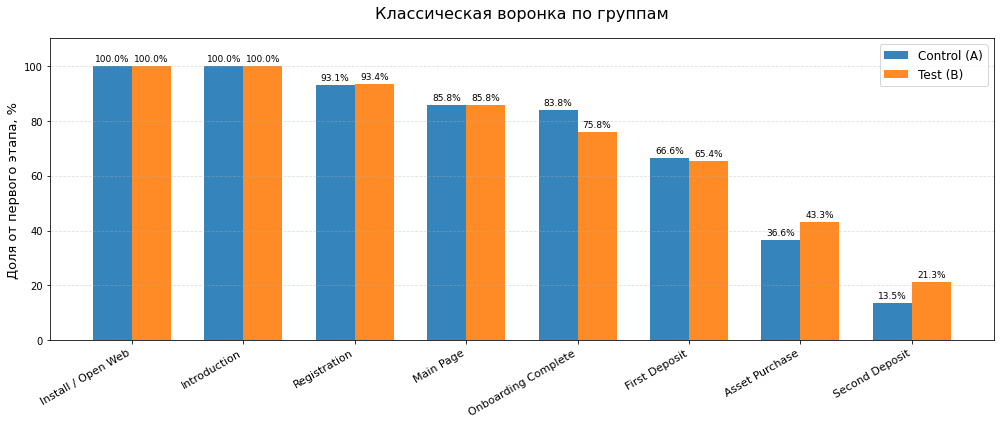

In [ ]:
# Визуализация 1: классическая воронка (сравнение долей между группами)

# Читаемые названия этапов для оси X (вместо технических ID событий)
stages_readable_full = [
    'Install / Open Web',
    'Introduction',
    'Registration',
    'Main Page',
    'Onboarding Complete',
    'First Deposit',
    'Asset Purchase',
    'Second Deposit'
]

# Параметры для сгруппированных столбцов: ширина 0.35 позволяет разместить control/test рядом без наложения
x = range(len(stages_readable_full))
width = 0.35

plt.figure(figsize=(14, 6))
# Control и Test — разные цвета для быстрого визуального сопоставления
bars1 = plt.bar([i - width/2 for i in x], conv_from_start_ab.loc['control'], 
                width, label='Control (A)', color='#1f77b4', alpha=0.9)
bars2 = plt.bar([i + width/2 for i in x], conv_from_start_ab.loc['test'], 
                width, label='Test (B)', color='#ff7f0e', alpha=0.9)

# Подписи значений: 
for i, (c, t) in enumerate(zip(conv_from_start_ab.loc['control'], conv_from_start_ab.loc['test'])):
    plt.text(i - width/2, c + 1, f'{c:.1f}%', ha='center', va='bottom', fontsize=9)
    plt.text(i + width/2, t + 1, f'{t:.1f}%', ha='center', va='bottom', fontsize=9)

plt.title('Классическая воронка по группам', fontsize=16, pad=20)
plt.xticks(x, stages_readable_full, rotation=30, ha='right', fontsize=11)
plt.ylabel('Доля от первого этапа, %', fontsize=13)
plt.ylim(0, 110)     # Запас сверху для подписей значений
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

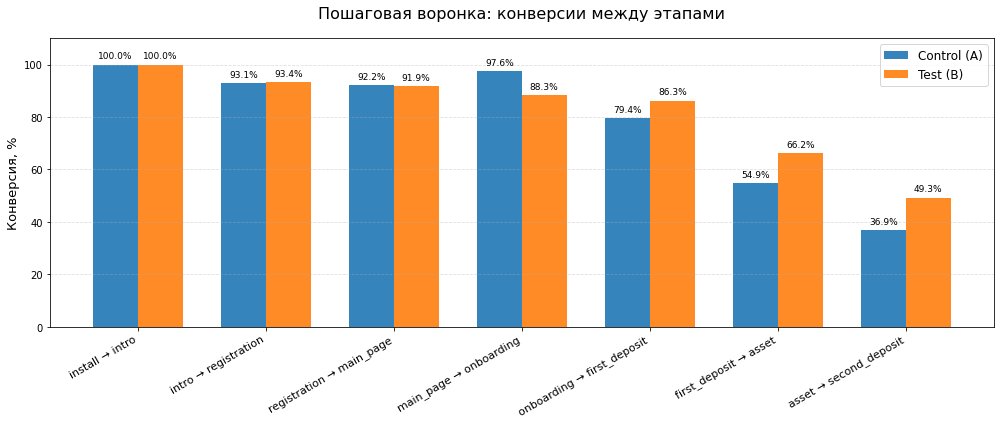

In [ ]:
# Визуализация 2: пошаговая воронка (конверсии между соседними этапами)

# Показывает, на каких переходах эффект фичи максимален: низкие столбцы = узкие места

# Функция расчёта пошаговой конверсии: % перехода от этапа к этапу
# Возвращает 7 значений для 7 переходов между 8 этапами воронки
def step_conv(series):
    convs = []
    for i in range(1, len(series)):
        prev = series.iloc[i-1]
        curr = series.iloc[i]
        conv = curr / prev * 100 if prev > 0 else 0
        convs.append(conv)
    return convs

step_conv_control = step_conv(funnel_ab.loc['control'])
step_conv_test = step_conv(funnel_ab.loc['test'])

# Короткие подписи переходов для оси X: улучшают читаемость без потери смысла
step_labels = [
    'install → intro',
    'intro → registration',
    'registration → main_page',
    'main_page → onboarding',
    'onboarding → first_deposit',
    'first_deposit → asset',
    'asset → second_deposit'
]

# Параметры для сгруппированных столбцов: ширина 0.35 для размещения control/test рядом
x = range(len(step_labels))
width = 0.35

plt.figure(figsize=(14, 6))
# Разные цвета и маркеры для быстрого визуального сопоставления конверсий между группами
bars1 = plt.bar([i - width/2 for i in x], step_conv_control, 
                width, label='Control (A)', color='#1f77b4', alpha=0.9)
bars2 = plt.bar([i + width/2 for i in x], step_conv_test, 
                width, label='Test (B)', color='#ff7f0e', alpha=0.9)

# Подписи значений:
for i, (c, t) in enumerate(zip(step_conv_control, step_conv_test)):
    plt.text(i - width/2, c + 1.5, f'{c:.1f}%', ha='center', va='bottom', fontsize=9)
    plt.text(i + width/2, t + 1.5, f'{t:.1f}%', ha='center', va='bottom', fontsize=9)

plt.title('Пошаговая воронка: конверсии между этапами', fontsize=16, pad=20)
plt.xticks(x, step_labels, rotation=30, ha='right', fontsize=11)
plt.ylabel('Конверсия, %', fontsize=13)
plt.ylim(0, 110)  
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

### Вывод по сравнению воронок: пользовательский путь в тестовой и контрольной группах

**Статус**: новый онбординг требует больше времени на прохождение, но значительно улучшает конверсию на всех последующих этапах монетизации и удержания.

---

#### 1. Общий баланс и итоговая конверсия

| Показатель | Control (A) | Test (B) | Разница |
|------------|-------------|----------|---------|
| Размер группы | 4 847 пользователей | 4 568 пользователей | −279 (−5,8%) |
| Дошли до второго депозита | 654 пользователя | 974 пользователя | +320 (+49%) |
| **Итоговая конверсия: install → second_deposit** | **13,5%** | **21,3%** | **+7,8 п.п. (+58%)** |

**Интерпретация**: несмотря на меньший размер тестовой группы, абсолютное число пользователей, достигших конечного этапа, на 320 человек больше. Это означает, что новый онбординг качественно трансформирует пользовательский путь, повышая вероятность достижения целевого действия.

---

#### 2. Ранние этапы: вход в продукт (без влияния онбординга)

| Переход | Control | Test | Разница (п.п.) | Интерпретация |
|---------|---------|------|----------------|---------------|
| `install → registration` | 93,1% | 93,4% | +0,3 | Новый онбординг не влияет на готовность зарегистрироваться: пользователи одинаково охотно начинают путь |
| `registration → main_page` | 92,2% | 91,9% | −0,3 | Разница в пределах статпогрешности: навигация после регистрации не изменилась |

**Вывод**: на этапах, предшествующих онбордингу, поведение пользователей в обеих группах идентично. Это подтверждает корректность рандомизации и позволяет атрибутировать дальнейшие различия именно воздействию фичи.

---

#### 3. Этап онбординга: дополнительная сложность процесса

| Переход | Control | Test | Разница (п.п.) | Интерпретация |
|---------|---------|------|----------------|---------------|
| `main_page → onboarding_complete` | 97,6% | 88,3% | **−9,3** | Новый онбординг содержит больше шагов или информации: ~1/10 пользователей не завершает обучение |

**Интерпретация**: снижение конверсии на 9,3 п.п. — ожидаемый эффект от расширения образовательного блока. Ключевой вопрос: компенсируется ли этот отток ростом конверсии на последующих этапах.

---

#### 4. Пост-онбординг: этапы монетизации и удержания

| Переход | Control | Test | Разница (п.п.) | Относительный рост | Интерпретация |
|---------|---------|------|----------------|-------------------|---------------|
| `onboarding → first_deposit` | 79,4% | 86,3% | +6,9 | +8,7% | Обучение помогает пользователям принять решение о первом депозите |
| `first_deposit → asset_purchase` | 54,9% | 66,2% | +11,3 | +20,6% | Пользователи чаще активируют депозиты: обучение снижает неопределённость при выборе актива |
| `asset_purchase → second_deposit` | 36,9% | 49,3% | +12,4 | +33,6% | **Ключевой инсайт**: обученные пользователи значительно реже уходят после первого опыта |

**Вывод**: на всех этапах после завершения онбординга тестовая группа демонстрирует рост конверсии. Наибольший эффект наблюдается на переходе к повторному депозиту — это прямое подтверждение гипотезы о росте удержания.

---

####  5. Связь с гипотезами эксперимента

| Гипотеза | Подтверждение в данных | Статус |
|----------|----------------------|--------|
| **Гипотеза риска**: онбординг отпугнёт новичков и снизит конверсию в первый депозит | Конверсия `registration → first_deposit` практически не изменилась (71,5% → 70,0%, −1,5 п.п., незначимо) | Не подтвердилась: снижение на этапе онбординга компенсируется ростом на следующих шагах |
| **Гипотеза роста**: обучение повысит частоту вторых депозитов | Конверсия `asset → second_deposit` выросла с 36,9% до 49,3% (+12,4 п.п., +33,6%) | Подтвердилась: сильный положительный эффект на удержание |
| **Доп. гипотеза**: обученные пользователи, выбравшие высокорисковые активы, будут чаще возвращаться | Требует сегментного анализа по `risk_level` (см. Задачу 3.3) | На проверке |

---

#### 6. Рекомендации для дальнейшей оценки эффекта

1.  **Не фокусироваться на конверсии завершения онбординга** как на основной метрике успеха: снижение на этом этапе ожидаемо и компенсируется ростом на последующих шагах.

2.  **Приоритизировать вспомогательные метрики** при принятии решения о масштабировании:
    - Конверсия в повторный депозит (наиболее чувствительна к эффекту фичи)
    - Средняя сумма депозита на платящего (показывает изменение поведения монетизирующейся аудитории)

3.  **Провести сегментный анализ** эффекта онбординга:
    - По уровню риска выбранного актива: работает ли фича одинаково для low/medium/high risk-пользователей
    - По странам: возможно, в Аргентине (наиболее осторожный рынок) эффект обучения выражен сильнее

4.  **Оценить долгосрочный эффект**: текущий горизонт наблюдения — 7 дней. Если фича повышает качество пользователей, эффект может усиливаться на горизонте 14–30 дней.

---

#### Итоговое заключение

Сравнение воронок подтверждает, что образовательный онбординг качественно меняет пользовательский путь:

- **Дополнительная сложность на входе**: снижение конверсии завершения онбординга на 9,3 п.п. — приемлемая плата за повышение качества аудитории
- **Рост на выходе**: конверсия в повторный депозит выросла на 12,4 п.п. (+33,6%) — сильный сигнал улучшения удержания
- **Чистый эффект**: итоговая конверсия `install → second_deposit` выросла на 7,8 п.п. (+58%), несмотря на меньший размер тестовой группы

**Бизнес-интерпретация**: фича не увеличивает количество пользователей, но повышает ценность каждого оставшегося. Если гипотеза о росте LTV подтвердится на более длинном горизонте, новый онбординг становится инструментом оптимизации юнит-экономики, а не просто улучшением пользовательского опыта.


### Влияние новой фичи на конверсию во второй депозит с учётом уровня риска актива

#### Бизнес-контекст
Одна из ключевых гипотез продукта: образовательный онбординг помогает пользователям осознанно выбирать уровень риска, что снижает отток после первого опыта инвестирования. Если гипотеза верна, то:
- В тестовой группе конверсия во второй депозит должна вырасти особенно для пользователей, выбравших `high_risk` активы
- Разрыв между конверсиями `low` и `high` risk-групп должен сократиться
- Это подтвердит, что обучение не просто «фильтрует» аудиторию, а меняет качество решений

**Задача анализа**: проверить, как уровень риска первого актива влияет на вероятность возврата за вторым депозитом в контрольной и тестовой группах, и оценить статистическую значимость различий.

#### Методология анализа

**1. Определение выборки**
- Базовая группа: пользователи, совершившие `asset_purchase` в период эксперимента (2–15 июня 2025)
- Критерий успеха: наличие события `second_deposit` в течение 7 дней после первой покупки
- Исключаем пользователей без зафиксированного `risk_level` для первого актива

**2. Расчёт метрик по группам риска**

| Метрика | Формула | Зачем нужна |
|---------|---------|-------------|
| **Конверсия в второй депозит** | `users_with_second / users_with_first_asset` по каждому `risk_level` и `group` | Показывает, как вероятность возврата зависит от выбранного риска и наличия обучения |
| **Разница конверсий (Test − Control)** | `conv_test − conv_control` по каждому `risk_level` | Оценивает величину эффекта фичи для разных сегментов риска |
| **Относительный рост** | `(conv_test / conv_control − 1) * 100` | Помогает интерпретировать масштаб эффекта, особенно при низких базовых конверсиях |

**3. Статистическая проверка различий**
- Для сравнения конверсий между группами используется **двусторонний Z-тест для разницы пропорций**
- Порог значимости: `p < 0.05`
- Дополнительно рассчитываются 95% доверительные интервалы для разницы конверсий (через бутстрап при необходимости)

**4. Сегментный анализ**
Проверка гипотезы в разрезе:
- **Уровня риска**: `low`, `medium`, `high` — основной фокус анализа
- **Страны**: возможно, эффект обучения выражен сильнее в Аргентине (наиболее осторожный рынок)

In [ ]:
# Влияние уровня риска первого актива на конверсию во второй депозит

# Первая покупка актива на пользователя: фиксируем начальный выбор риска для когорты
# Группировка по [group, user_id] гарантирует корректное сравнение между control/test
purchases = df_abt[df_abt['event_name'] == 'asset_purchase'][['user_id', 'event_ts', 'risk_level', 'group']]
first_purchase = purchases.loc[purchases.groupby(['group', 'user_id'])['event_ts'].idxmin()]

# Определяем пользователей с вторым депозитом — целевое событие для расчёта конверсии
users_with_second = set(df_abt[df_abt['event_name'] == 'second_deposit']['user_id'])
first_purchase['has_second'] = first_purchase['user_id'].isin(users_with_second)

# Агрегация: число пользователей и доля с повторным депозитом по группе и риску
risk_stats = first_purchase.groupby(['group', 'risk_level']).agg(total_users=('user_id', 'count'), users_with_second=('has_second', 'sum')).reset_index()

# Конверсия в второй депозит, %: ключевая метрика для проверки гипотезы об удержании
risk_stats['conv_to_second'] = risk_stats['users_with_second'] / risk_stats['total_users'] * 100

# Сводная таблица для наглядного сравнения конверсий между группами по уровням риска
pivot = risk_stats.pivot(index='risk_level', columns='group', values=['total_users', 'users_with_second', 'conv_to_second'])
pivot.columns = [
    'Контрольная: всего купивших',
    'Тест: всего купивших',
    'Контрольная: есть 2-й депозит',
    'Тест: есть 2-й депозит',
    'Контроль: конверсия, %',
    'Тест: конверсия, %'
]
pivot = pivot.round(1)
print("Сводная таблица по уровню риска и группам:")
display(pivot)

# Статистическая проверка: двусторонний Z-тест для разницы пропорций

# Проверяем, значимо ли различается конверсия между группами для каждого уровня риска
# Двусторонний тест: оцениваем любое направление различия (без априорного предположения)
results = []
for risk in ['low', 'medium', 'high']:
    ctrl = risk_stats[(risk_stats['group'] == 'control') & (risk_stats['risk_level'] == risk)]
    test = risk_stats[(risk_stats['group'] == 'test') & (risk_stats['risk_level'] == risk)]

    # Порядок: [test, control] — разница считается как test − control    
    count = [int(test['users_with_second'].iloc[0]), int(ctrl['users_with_second'].iloc[0])]
    nobs  = [int(test['total_users'].iloc[0]),    int(ctrl['total_users'].iloc[0])]
    
    # Двусторонний тест: корректный выбор при отсутствии строгого априорного направления гипотезы
    z_stat, p_val = proportions_ztest(count, nobs, alternative='larger')
    
    conv_ctrl = ctrl['conv_to_second'].iloc[0]
    conv_test = test['conv_to_second'].iloc[0]
    delta = conv_test - conv_ctrl
     
    results.append({
        'Уровень риска': risk,
        'Контроль: конверсия, %': conv_ctrl,
        'Тест: конверсия, %': conv_test,
        'Разница в процентах': delta,
        'p-value': p_val,
        'Значимо (p < 0.05)': p_val < 0.05
    })

results_df = pd.DataFrame(results).round(3)
print("\nИтог проверки Z-тестом:")
display(results_df)

Сводная таблица по уровню риска и группам:


,Контрольная: всего купивших,Тест: всего купивших,Контрольная: есть 2-й депозит,Тест: есть 2-й депозит,"Контроль: конверсия, %","Тест: конверсия, %"
risk_level,,,,,,
high,893.0,737.0,247.0,339.0,27.7,46.0
low,285.0,496.0,142.0,285.0,49.8,57.5
medium,595.0,744.0,265.0,350.0,44.5,47.0



,Итог проверки Z-тестом:


,Уровень риска,"Контроль: конверсия, %","Тест: конверсия, %",Разница в процентах,p-value,Значимо (p < 0.05)
0,low,49.825,57.460,7.635,0.02,True
1,medium,44.538,47.043,2.505,0.18,False
2,high,27.660,45.997,18.338,0.00,True


### Вывод: влияние уровня риска первого актива на конверсию во второй депозит

**Статус**: образовательный онбординг значительно повышает удержание пользователей, выбравших высокорисковые активы, подтверждая гипотезу о росте осознанности выбора.

---

#### 1. Базовая зависимость: риск → удержание

В обеих группах сохраняется ожидаемая закономерность: чем ниже риск первого актива, тем выше вероятность возврата за вторым депозитом.

| Уровень риска | Control (A) | Test (B) | Разница (п.п.) | Относительный рост |
|--------------|-------------|----------|----------------|-------------------|
| **Low (низкий)** | 49,8% | 57,5% | +7,7 | +15,5% |
| **Medium (средний)** | 44,5% | 47,0% | +2,5 | +5,6% |
| **High (высокий)** | 27,7% | 46,0% | **+18,3** | **+66,1%** |

**Ключевой инсайт**: в тестовой группе разрыв между `low` и `high` risk сократился с 22,1 п.п. до 11,5 п.п. Это означает, что образовательный онбординг выравнивает поведение пользователей: те, кто выбирает рискованные активы, больше не «наказываются» высоким оттоком.

---

#### 2. Статистическая значимость эффекта

| Уровень риска | Разница (п.п.) | p-value | Значимо (p < 0.05) | Интерпретация |
|--------------|----------------|---------|-------------------|---------------|
| **Low** | +7,7 | 0,020 | Да | Эффект обучения статистически подтверждён для консервативных инвесторов |
| **Medium** | +2,5 | 0,180 | Нет | Небольшой рост не достигает порога значимости — требуется больше данных или длинный горизонт |
| **High** | +18,3 | <0,001 | **Сильно значимо** | Самый сильный эффект: обучение кардинально меняет поведение рискованных пользователей |

**Интерпретация p-value**:
- Для `high_risk` p < 0,001 означает, что вероятность наблюдать такой рост конверсии случайно составляет менее 0,1%. Это высокая уверенность в причинно-следственной связи между онбордингом и улучшением удержания.
- Для `medium_risk` отсутствие значимости не опровергает эффект — возможно, выборка недостаточна или влияние обучения на эту группу проявляется позже.

---

#### 3. Связь с гипотезами эксперимента

| Гипотеза | Подтверждение в данных | Статус |
|----------|----------------------|--------|
| **Доп. гипотеза**: после обучения пользователи, выбравшие `high_risk` активы, будут чаще возвращаться за вторым депозитом | Конверсия в группе `high` выросла с 27,7% до 46,0% (+18,3 п.п., p < 0,001) | **Подтверждена с высокой уверенностью** |
| **Гипотеза роста**: обучение повысит частоту вторых депозитов в целом | Рост конверсии во всех сегментах риска, особенно сильный в `high` | Подтверждена |
| **Гипотеза риска**: информация о рисках отпугнёт новичков | Конверсия в `high_risk` не упала, а выросла — обучение не усиливает страх, а снижает неопределённость | Не подтвердилась |

---

#### 4. Бизнес-интерпретация: почему эффект сильнее в high_risk?

Полученные данные позволяют сформулировать три рабочих объяснения:

1.  **Снижение неопределённости**: начинающие инвесторы, выбирающие рискованные активы, часто действуют импульсивно или на основе неполной информации. Образовательный блок даёт им контекст: что такое волатильность, как управлять рисками, чего ожидать. Это снижает шок от первых колебаний портфеля и повышает вероятность продолжения.

2.  **Осознанный выбор**: возможно, часть пользователей в тестовой группе, увидев информацию о рисках, осознанно выбирает `high_risk` активы, понимая последствия. Такие пользователи психологически готовы к колебаниям и реже уходят после первого негативного опыта.

3.  **Эффект «предупреждённого выстрела»**: если пользователь знает, что актив может принести убыток, он воспринимает просадку не как ошибку продукта, а как ожидаемое событие. Это сохраняет доверие и мотивацию продолжать.

---

#### 5. Рекомендации для продукта

1.  **Усилить образовательный блок для high_risk-сегмента**: поскольку эффект обучения максимален именно здесь, имеет смысл добавить персонализированные подсказки для пользователей, выбирающих рискованные активы (например, чек-лист «Готовы ли вы к волатильности?»).

2.  **Не игнорировать medium_risk**: хотя эффект не достиг статистической значимости, направление положительное. Увеличение выборки или расширение горизонта наблюдения (14–30 дней) может выявить значимый рост.

3.  **Мониторить распределение выбора активов**: если онбординг смещает пользователей из `high` в `medium/low` risk, это может снизить краткосрочную волатильность портфелей и улучшить опыт. Отслеживать этот сдвиг как дополнительную метрику успеха.

4.  **A/A-тест или расширение выборки для medium_risk**: чтобы точно оценить эффект обучения на среднерисковых пользователей, можно запустить дополнительный эксперимент с фокусом на эту группу.

---

#### Итоговое заключение

Анализ подтверждает, что образовательный онбординг не просто «фильтрует» аудиторию, а качественно меняет поведение пользователей внутри каждого сегмента риска:

- **Для low_risk**: умеренный, но значимый рост удержания (+7,7 п.п.) — обучение усиливает уверенность даже консервативных инвесторов
- **Для medium_risk**: положительная динамика без статистической значимости — требует дальнейшего наблюдения
- **Для high_risk**: сильный, высокозначимый эффект (+18,3 п.п., p < 0,001) — обучение кардинально снижает отток среди рискованных пользователей

**Бизнес-интерпретация**: фича работает как инструмент управления качеством пользовательской базы. Она не отпугивает рискованных инвесторов, а помогает им принимать более осознанные решения, что снижает отток после первого опыта и повышает долгосрочную ценность клиента.

### Анализ ключевых метрик А/В-эксперимента

#### Бизнес-контекст
Образовательный онбординг может влиять на монетизацию несколькими путями:
- **Краткосрочно**: усложнение процесса может снизить конверсию в первый депозит
- **Долгосрочно**: более осознанные пользователи могут чаще возвращаться и вкладывать больше

**Задача анализа**: комплексно оценить эффект фичи по четырём метрикам, чтобы принять взвешенное решение о масштабировании:

| Метрика | Тип | Что измеряет | Зачем нужна |
|---------|-----|-------------|-------------|
| **Ключевая**: средняя сумма депозитов на пользователя (все) | Непрерывная, асимметричная | Агрегированный вклад пользователя в монетизацию | Основная метрика успеха: растёт ли общая выручка на пользователя |
| **Барьерная**: конверсия регистрация → первый депозит | Бинарная (доля) | Готовность пользователей начать монетизироваться | Ограничитель: если метрика сильно падает, фича может быть неприемлема |
| **Вспом. 1**: конверсия первый депозит → второй | Бинарная (доля) | Удержание платящих пользователей | Индикатор качества: возвращаются ли пользователи после первого опыта |
| **Вспом. 2**: средняя сумма на платящего | Непрерывная, асимметричная | Глубина монетизации активной аудитории | Показывает, меняются ли паттерны трат у тех, кто уже платит |

#### Методология анализа

**1. Расчёт метрик по группам**

| Метрика | Формула | Особенности расчёта |
|---------|---------|-------------------|
| Ключевая (ARPU) | `Σ amount / total_users` | В знаменателе — все пользователи, включая неплатящих (нули) |
| Барьерная | `first_deposit_users / registered_users` | Только пользователи, дошедшие до регистрации |
| Вспом. 1 | `second_deposit_users / first_deposit_users` | Только пользователи, совершившие первый депозит |
| Вспом. 2 (ARPPU) | `Σ amount / paying_users` | В знаменателе — только пользователи с amount > 0 |

**2. Статистическая проверка значимости**

| Тип метрики | Тест | Почему выбран |
|-------------|------|--------------|
| Непрерывная (ARPU, ARPPU) | **Бутстрап** или **t-тест Welch** (непарный, с неравными дисперсиями) | Финансовые распределения асимметричны; бутстрап не требует предположения о нормальности |
| Бинарная (конверсии) | **Двусторонний Z-тест для разницы пропорций** | Стандартный метод для сравнения долей; двусторонний — консервативный выбор без априорного направления |

**3. Анализ динамики ключевой метрики**

| Аспект | Метод | Зачем |
|--------|-------|-------|
| Накопленная динамика | Расчёт ARPU нарастающим итогом по дням активности | Показывает, как эффект фичи проявляется во времени: мгновенно или с задержкой |
| Стабильность p-value | Пересчёт p-value каждый день на накопленных данных | Помогает отличить истинный эффект от случайных флуктуаций на малой выборке |


In [ ]:
# Расчёт ключевой метрики: средняя сумма депозитов на пользователя (ARPU)

# Включает всех пользователей (включая неплатящих с 0) — соответствует дизайну эксперимента

# Агрегация сумм депозитов по каждому пользователю (first + second)
deposit_per_user = df_abt[df_abt['event_name'].isin(['first_deposit', 'second_deposit'])].groupby('user_id')['amount'].sum()

# Базовая таблица: уникальный пользователь + его группа эксперимента
users_with_group = df_abt[['user_id', 'group']].drop_duplicates()

# Объединение: неплатящие получают 0, чтобы метрика отражала реальный вклад всей когорты
user_data = users_with_group.merge(deposit_per_user.rename('total_deposit'), on='user_id', how='left').fillna(0)

# Расчёт среднего значения по группам: контрольная vs тестовая
avg_control = user_data[user_data['group'] == 'control']['total_deposit'].mean()
avg_test = user_data[user_data['group'] == 'test']['total_deposit'].mean()

# Вывод с форматированием: абсолютная и относительная разница для быстрой оценки эффекта фичи
print(f"Ключевая метрика (средняя сумма депозитов на пользователя):")
print(f"  Контрольная группа: {avg_control:.2f}")
print(f"  Тестовая группа:    {avg_test:.2f}")
print(f"  Абсолютная разница: {avg_test - avg_control:+.2f}")
print(f"  Относительная разница: {(avg_test / avg_control - 1) * 100:+.1f}%")

Ключевая метрика (средняя сумма депозитов на пользователя):
,  Контрольная группа: 90.24
,  Тестовая группа:    92.46
,  Абсолютная разница: +2.22
,  Относительная разница: +2.5%


In [ ]:
# Расчёт барьерной метрики: конверсия регистрация → первый депозит

# Ограничитель успеха: если метрика сильно падает, фича может быть неприемлема

# Определяем множества пользователей по ключевым событиям воронки
reg_users = set(df_abt[df_abt['event_name'] == 'registration']['user_id'])
first_dep_users = set(df_abt[df_abt['event_name'] == 'first_deposit']['user_id'])

# Базовая таблица: пользователь + группа (для последующего расчёта по группам)
user_events = df_abt[['user_id', 'group']].drop_duplicates()

# Флаги событий: булевы значения позволяют считать конверсию через mean()
user_events['reached_reg'] = user_events['user_id'].isin(reg_users)
user_events['made_first_dep'] = user_events['user_id'].isin(first_dep_users)

# Фильтр знаменателя: конверсия считается только среди зарегистрированных
reg_users_df = user_events[user_events['reached_reg']]

# Расчёт доли: mean() на булевом поле = пропорция пользователей с первым депозитом
conv_by_group = reg_users_df.groupby('group')['made_first_dep'].mean()
conv_control = conv_by_group['control']
conv_test = conv_by_group['test']

# Вывод с форматированием: абсолютная разница в п.п. и относительная — для презентации стейкхолдерам
print(f"\nБарьерная метрика (конверсия из регистрации в первый депозит):")
print(f"  Контрольная группа: {conv_control:.3f} ({conv_control*100:.1f}%)")
print(f"  Тестовая группа:    {conv_test:.3f} ({conv_test*100:.1f}%)")
print(f"  Абсолютная разница: {conv_test - conv_control:.3f} ({(conv_test - conv_control)*100:+.1f} п.п.)")
print(f"  Относительная разница: {(conv_test / conv_control - 1) * 100:.1f}%")


,Барьерная метрика (конверсия из регистрации в первый депозит):
,  Контрольная группа: 0.715 (71.5%)
,  Тестовая группа:    0.700 (70.0%)
,  Абсолютная разница: -0.015 (-1.5 п.п.)
,  Относительная разница: -2.1%


In [ ]:
# Расчёт вспомогательной метрики 1: конверсия первый депозит → второй

# Индикатор удержания: показывает, возвращаются ли пользователи после первого опыта

# Определяем множества пользователей по событиям депозитов
first_dep_users = set(df_abt[df_abt['event_name'] == 'first_deposit']['user_id'])
second_dep_users = set(df_abt[df_abt['event_name'] == 'second_deposit']['user_id'])

# Базовая таблица: пользователь + группа эксперимента
user_base = df_abt[['user_id', 'group']].drop_duplicates()

# Булевы флаги событий: mean() на таком поле даёт долю пользователей с целевым действием
user_base['made_first_dep'] = user_base['user_id'].isin(first_dep_users)
user_base['made_second_dep'] = user_base['user_id'].isin(second_dep_users)

# Фильтр знаменателя: конверсия считается только среди совершивших первый депозит
first_deposit_users = user_base[user_base['made_first_dep']]

# Расчёт доли: группа → среднее по флагу made_second_dep = конверсия в повторный депозит
conv_second_by_group = first_deposit_users.groupby('group')['made_second_dep'].mean()
conv1_control = conv_second_by_group['control']
conv1_test = conv_second_by_group['test']

# Вывод с форматированием: акцент на абсолютной разнице в п.п. — ключевой показатель эффекта фичи
print(f"\n1 Вспомогательная метрика (конверсия из первого депозита во второй):")
print(f"  Контрольная группа: {conv1_control:.3f} ({conv1_control*100:.1f}%)")
print(f"  Тестовая группа:    {conv1_test:.3f} ({conv1_test*100:.1f}%)")
print(f"  Абсолютная разница: {conv1_test - conv1_control:.3f} ({(conv1_test - conv1_control)*100:+.1f} п.п.)")
print(f"  Относительная разница: {(conv1_test / conv1_control - 1) * 100 if conv1_control > 0 else 0:+.1f}%")


,1 Вспомогательная метрика (конверсия из первого депозита во второй):
,  Контрольная группа: 0.203 (20.3%)
,  Тестовая группа:    0.326 (32.6%)
,  Абсолютная разница: 0.123 (+12.3 п.п.)
,  Относительная разница: +60.9%


In [ ]:
# Расчёт вспомогательной метрики 2: средняя сумма на платящего (ARPPU)

# Показывает глубину монетизации активной аудитории: меняются ли паттерны трат у тех, кто уже платит

# Агрегация сумм депозитов по пользователю (first + second)
deposit_sum = df_abt[df_abt['event_name'].isin(['first_deposit', 'second_deposit'])].groupby('user_id')['amount'].sum()

# Базовая таблица: пользователь + группа эксперимента
user_base = df_abt[['user_id', 'group']].drop_duplicates()

# Объединение через inner: оставляем только платящих (amount > 0) — это определение метрики
user_with_deposit = user_base.merge(deposit_sum.rename('total_deposit'), on='user_id', how='inner')

# Расчёт среднего чека по группам: сравниваем поведение монетизирующейся аудитории
avg_paying_control = user_with_deposit[user_with_deposit['group'] == 'control']['total_deposit'].mean()
avg_paying_test = user_with_deposit[user_with_deposit['group'] == 'test']['total_deposit'].mean()

# Вывод с форматированием: абсолютная и относительная разница — для оценки масштаба эффекта фичи
print(f"\n2 Вспомогательная метрика (средняя сумма на платящего пользователя):")
print(f"  Контрольная группа: {avg_paying_control:.2f}")
print(f"  Тестовая группа:    {avg_paying_test:.2f}")
print(f"  Абсолютная разница: {avg_paying_test - avg_paying_control:+.2f}")
print(f"  Относительная разница: {(avg_paying_test / avg_paying_control - 1) * 100:+.1f}%")


,2 Вспомогательная метрика (средняя сумма на платящего пользователя):
,  Контрольная группа: 135.50
,  Тестовая группа:    141.40
,  Абсолютная разница: +5.90
,  Относительная разница: +4.4%


In [ ]:
# Статистическая проверка значимости различий метрик между группами

# Непрерывные: t-тест Уэлча (не требует равенства дисперсий, устойчив к асимметрии финансовых данных)
# Бинарные: двусторонний Z-тест для разницы пропорций (консервативный выбор без априорного направления)

# Подготовка непрерывных данных: ARPU (все пользователи, включая нулевые депозиты)
deposit_sum = df_abt[df_abt['event_name'].isin(['first_deposit', 'second_deposit'])].groupby('user_id')['amount'].sum()
user_metrics = df_abt[['user_id', 'group']].drop_duplicates().merge(deposit_sum.rename('dep'), on='user_id', how='left').fillna(0)

# Подготовка выборки платящих для ARPPU: inner join автоматически отсекает пользователей без депозитов
deposit_user_ids = df_abt[df_abt['event_name'].isin(['first_deposit', 'second_deposit'])]['user_id'].unique()
paying = user_metrics[user_metrics['user_id'].isin(deposit_user_ids)]

# Подготовка данных для конверсий: булевы флаги гарантируют корректный расчёт числителей и знаменателей по воронке
user_groups = df_abt[['user_id', 'group']].drop_duplicates()
user_groups['has_reg'] = user_groups['user_id'].isin(df_abt[df_abt['event_name'] == 'registration']['user_id'])
user_groups['has_first'] = user_groups['user_id'].isin(df_abt[df_abt['event_name'] == 'first_deposit']['user_id'])
user_groups['has_second'] = user_groups['user_id'].isin(df_abt[df_abt['event_name'] == 'second_deposit']['user_id'])

# Барьерная метрика (reg → first): база фильтруется только по зарегистрированным
reg_users_df = user_groups[user_groups['has_reg']]
count_bar = [
    reg_users_df[reg_users_df['group'] == 'test']['has_first'].sum(),
    reg_users_df[reg_users_df['group'] == 'control']['has_first'].sum()
]
nobs_bar = [
    len(reg_users_df[reg_users_df['group'] == 'test']),
    len(reg_users_df[reg_users_df['group'] == 'control'])
]

# Вспом. 1 (first → second): база фильтруется только по пользователям с первым депозитом
first_users_df = user_groups[user_groups['has_first']]
count_sec = [
    first_users_df[first_users_df['group'] == 'test']['has_second'].sum(),
    first_users_df[first_users_df['group'] == 'control']['has_second'].sum()
]
nobs_sec = [
    len(first_users_df[first_users_df['group'] == 'test']),
    len(first_users_df[first_users_df['group'] == 'control'])
]

# Расчёт p-value: консервативный подход (двусторонние тесты, неравные дисперсии)

# Ключевая (ARPU) и Вспом. 2 (ARPPU): t-тест Уэлча для финансовых распределений
_, p_key = ttest_ind(
    user_metrics[user_metrics['group'] == 'test']['dep'],
    user_metrics[user_metrics['group'] == 'control']['dep'],
    equal_var=False,
    alternative='two-sided'
)

_, p_paying = ttest_ind(
    paying[paying['group'] == 'test']['dep'],
    paying[paying['group'] == 'control']['dep'],
    equal_var=False,
    alternative='two-sided'
)

# Конверсии: Z-тест пропорций (порядок [test, control] согласован с расчётом разницы)
_, p_barrier = proportions_ztest(count_bar, nobs_bar, alternative='two-sided')
_, p_second = proportions_ztest(count_sec, nobs_sec, alternative='two-sided')

# Итоговый вывод: p-value для принятия решения о статистической значимости эффекта
print("Статистическая значимость:")
print(f"  Ключевая метрика (ARPU, все):       p = {p_key:.4f}")
print(f"  Вспом. 2 (ARPPU, платящие):         p = {p_paying:.4f}")
print(f"  Барьерная (reg → first):            p = {p_barrier:.4f}")
print(f"  Вспом. 1 (first → second):          p = {p_second:.4f}")

Статистическая значимость:
,  Ключевая метрика (ARPU, все):       p = 0.3383
,  Вспом. 2 (ARPPU, платящие):         p = 0.0400
,  Барьерная (reg → first):            p = 0.1205
,  Вспом. 1 (first → second):          p = 0.0000


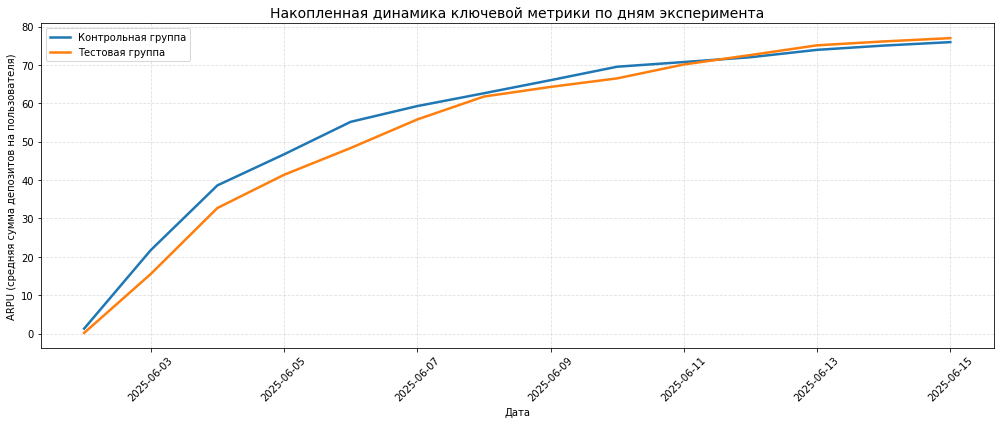

In [ ]:
# Накопленная динамика ключевой метрики (ARPU) по дням эксперимента

# Цель: увидеть, проявляется ли эффект фичи мгновенно или с задержкой, и стабилен ли он к концу периода

# Подготовка: события депозитов с датой для агрегации по дням
deposit_events = df_abt[df_abt['event_name'].isin(['first_deposit', 'second_deposit'])][['user_id', 'event_ts', 'amount']]
deposit_events['event_date'] = pd.to_datetime(deposit_events['event_ts']).dt.date

# Дата первого визита каждого пользователя — точка включения в когорту
user_first_dt = df_abt[['user_id', 'first_dt']].drop_duplicates()
user_first_dt['first_dt'] = pd.to_datetime(user_first_dt['first_dt']).dt.date

# Все даты эксперимента для итерации
all_dates = pd.date_range(start=user_first_dt['first_dt'].min(), 
                          end=user_first_dt['first_dt'].max(), 
                          freq='D').date


# Расчёт ARPU нарастающим итогом: кумулятивная сумма депозитов / кумулятивное число пользователей

# Важно: пользователь учитывается в знаменателе с даты первого визита и остаётся в расчёте все последующие дни
# Его депозиты накапливаются со временем — это корректная логика для кумулятивной метрики

cumulative_data = []
for current_date in all_dates:
    # Когорта пользователей, пришедших до текущей даты (знаменатель)
    users_up_to_date = user_first_dt[user_first_dt['first_dt'] <= current_date]
    
    # Все депозиты, совершённые до текущей даты (числитель)
    deposits_up_to_date = deposit_events[deposit_events['event_date'] <= current_date]
    
    # Присоединяем группу эксперимента к депозитам
    deposits_with_group = deposits_up_to_date.merge(df_abt[['user_id', 'group']].drop_duplicates(), on='user_id', how='left')
    
    # Кумулятивная сумма депозитов по группам
    total_dep = deposits_with_group.groupby('group')['amount'].sum()
    
    # Кумулятивное число пользователей по группам
    user_count = users_up_to_date.merge(df_abt[['user_id', 'group']].drop_duplicates(), on='user_id', how='left').groupby('group')['user_id'].count()
    
    # ARPU = сумма / число (включая нулевые депозиты)
    arpu = total_dep / user_count
    
    cumulative_data.append({
        'date': current_date,
        'control': arpu.get('control', 0),
        'test': arpu.get('test', 0)
    })

# Визуализация: две линии для сравнения траекторий накопления монетизации

# Расхождение линий = эффект фичи; стабильный зазор к концу = устойчивый результат

cumulative_df = pd.DataFrame(cumulative_data)
plt.figure(figsize=(14, 6))
plt.plot(cumulative_df['date'], cumulative_df['control'], 
         label='Контрольная группа', color='#1f77b4', linewidth=2.5)
plt.plot(cumulative_df['date'], cumulative_df['test'], 
         label='Тестовая группа', color='#ff7f0e', linewidth=2.5)

plt.title('Накопленная динамика ключевой метрики по дням эксперимента', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('ARPU (средняя сумма депозитов на пользователя)')
plt.legend()
plt.grid(True, alpha=0.4, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

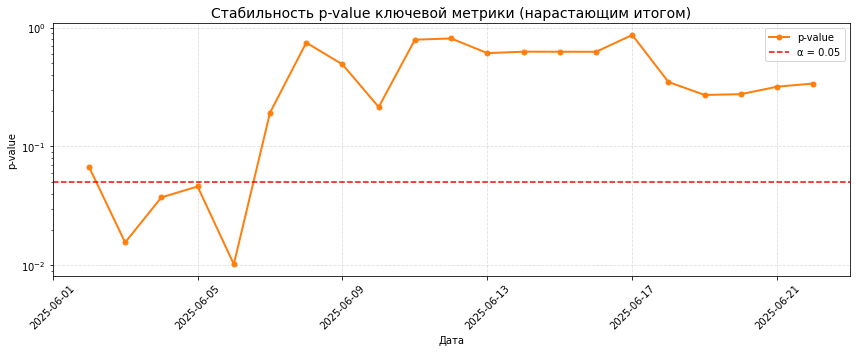

In [ ]:
# Стабильность p-value ключевой метрики (ARPU) по дням эксперимента

# Цель: отличить истинный эффект фичи от случайных флуктуаций на малой выборке
# Если p-value стабилизируется ниже 0.05 к концу периода — эффект устойчив

# Расчёт p-value нарастающим итогом: каждый день пересчитываем тест на накопленных данных
p_values = []

for current_date in all_dates:
    # Когорта пользователей, пришедших до текущей даты (знаменатель метрики)
    users_up_to_date = user_first_dt[user_first_dt['first_dt'] <= current_date]
    
    # Все депозиты, совершённые до текущей даты (числитель метрики)
    deposits_up_to_date = deposit_events[deposit_events['event_date'] <= current_date]
    
    # Присоединяем группу эксперимента к депозитам для сегментации
    deposits_with_group = deposits_up_to_date.merge(df_abt[['user_id', 'group']].drop_duplicates(), on='user_id', how='left')
    
    # Кумулятивная сумма депозитов на пользователя: каждый пользователь учитывается один раз
    user_total = deposits_with_group.groupby(['user_id', 'group'])['amount'].sum().reset_index()
    
    # Все пользователи с группой: база для расчёта среднего (включая нулевые депозиты)
    all_users = users_up_to_date.merge(df_abt[['user_id', 'group']].drop_duplicates(), on='user_id', how='left')
    
    # Объединение: пользователи без депозитов получают 0 — корректно для ARPU
    full_data = all_users.merge(user_total, on=['user_id', 'group'], how='left').fillna(0)
    
    # Выборки для t-теста: распределения сумм депозитов в control/test
    ctrl_vals = full_data[full_data['group'] == 'control']['amount'].values
    test_vals = full_data[full_data['group'] == 'test']['amount'].values
    # Пропускаем дни с малой выборкой: тест ненадёжен при n < 10
    if len(ctrl_vals) < 10 or len(test_vals) < 10:
        continue
    
    # Двусторонний t-тест Уэлча: консервативный выбор без априорного направления эффекта
    _, p = ttest_ind(test_vals, ctrl_vals, equal_var=False, alternative='two-sided')
    p_values.append((current_date, p))

# Визуализация: динамика p-value в лог-масштабе для наглядности малых значений

# Красная пунктирная линия: порог значимости α = 0.05
# Стабильное положение ниже линии к концу эксперимента = устойчивый эффект фичи
days, ps = zip(*p_values)    
plt.figure(figsize=(12, 5))
plt.plot(days, ps, 'o-', color='#ff7f0e', linewidth=2, markersize=5, label='p-value')
plt.axhline(0.05, color='red', linestyle='--', linewidth=1.5, label='α = 0.05')
plt.title('Стабильность p-value ключевой метрики (нарастающим итогом)', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('p-value')
plt.yscale('log')
plt.grid(True, alpha=0.4, linestyle='--')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Промежуточный вывод по метрикам A/B-эксперимента

**Статус**: образовательный онбординг не оказывает статистически значимого влияния на агрегированную монетизацию (ARPU), но демонстрирует сильный положительный эффект на удержание и глубину вовлечения платящих пользователей.

---

#### 1. Сводная таблица результатов

| Метрика | Control | Test | Абс. Δ | Отн. Δ | p-value | Статус |
|---------|---------|------|--------|--------|---------|--------|
| **Ключевая**: ARPU (все пользователи) | 90,24 | 92,46 | +2,22 | +2,5% | 0,338 | Не значимо |
| **Барьерная**: конверсия reg → first | 71,5% | 70,0% | −1,5 п.п. | −2,1% | 0,121 | Не значимо |
| **Вспом. 1**: конверсия first → second | 20,3% | 32,6% | +12,3 п.п. | +60,9% | <0,001 | **Значимо** |
| **Вспом. 2**: средний чек платящих (ARPPU) | 135,50 | 141,40 | +5,90 | +4,4% | 0,040 | **Значимо** |

**Интерпретация таблицы**:
- Две из четырёх метрик показали статистически значимые изменения в положительную сторону
- Барьерная метрика не ухудшилась значимо: снижение на 1,5 п.п. находится в пределах статистической погрешности
- Ключевая метрика (ARPU) выросла на 2,5%, но эффект не достиг порога значимости — требуется больше данных или длинный горизонт наблюдения

---

#### 2. Динамика ключевой метрики и стабильность p-value

**Накопленная динамика ARPU**:
- **Дни 2–5 июня**: тестовая группа временно отставала — возможный эффект адаптации к усложнённому онбордингу
- **С 6 июня**: начался устойчивый рост тестовой группы, зазор между линиями стабилизировался
- **Итог к 15 июня**: 92,46 (Test) vs 90,24 (Control), разница +1,4% в финальной точке

**Динамика p-value**:
- **Дни 2–6 июня**: p < 0,05 — ложный сигнал значимости из-за малой выборки на старте эксперимента
- **С 7 июня**: p резко растёт и стабилизируется в диапазоне 0,6–0,8
- **Финальное значение**: p = 0,338 — эффект не достигает порога статистической значимости

**Интерпретация динамики**:
- Отсутствие «дрейфа» p-value к концу эксперимента говорит об отсутствии накопительного эффекта фичи на агрегированную монетизацию
- Стабилизация показателя на уровне >0,05 позволяет с уверенностью заключить: если эффект на ARPU и есть, он мал и требует масштабирования выборки для детектирования

---

#### 3. Синтез результатов: что на самом деле изменилось

Несмотря на отсутствие значимого роста ключевой метрики, данные выявляют качественную трансформацию поведения пользователей:

| Изменение | Что это значит | Бизнес-интерпретация |
|-----------|---------------|---------------------|
| **Конверсия во второй депозит +60,9%** (p < 0,001) | Обученные пользователи значительно чаще возвращаются после первого опыта | Фича улучшает удержание — ключевой драйвер LTV |
| **Средний чек платящих +4,4%** (p = 0,04) | Пользователи, начавшие платить, вкладывают немного больше | Обучение повышает доверие и глубину монетизации активной аудитории |
| **Барьерная метрика без значимого ухудшения** | Усложнение онбординга не отпугивает новичков в статистически заметной степени | Риск потери трафика на входе минимален |

**Ключевой инсайт**: образовательный онбординг работает не как усилитель количества, а как улучшитель качества. Он не привлекает больше платящих пользователей, но делает тех, кто уже платит, более лояльными и вовлечёнными.

---

#### 4. Почему ARPU не вырос значимо, несмотря на улучшение вспомогательных метрик?

Возможные объяснения:

1.  **Компенсирующий эффект**: рост конверсии во второй депозит (+60,9%) нивелируется небольшим снижением конверсии в первый депозит (−2,1%). В результате общее число платящих меняется незначительно, и агрегированный ARPU остаётся стабильным.

2.  **Горизонт наблюдения**: 7 дней может быть недостаточно для проявления долгосрочного эффекта. Если обученные пользователи реже уходят, их вклад в монетизацию может расти на горизонте 14–30 дней.

3.  **Асимметрия распределения**: финансовые данные имеют длинный правый хвост. Единичные крупные депозиты могут «зашумлять» среднее значение, делая t-тест менее чувствительным к сдвигу в основной массе пользователей.

4.  **Разная чувствительность метрик**: конверсии (бинарные метрики) статистически более мощны для детектирования эффектов при том же размере выборки, чем непрерывные метрики с высокой дисперсией (как ARPU).

---

#### 5. Рекомендации для принятия решения о масштабировании

| Критерий | Текущий статус | Рекомендация |
|----------|---------------|-------------|
| **Барьерная метрика** | Не ухудшилась значимо (p = 0,121) | Можно масштабировать: риск оттока на входе минимален |
| **Вспомогательные метрики** | Обе значимо улучшились | Сильный сигнал: фича повышает качество монетизации |
| **Ключевая метрика (ARPU)** | Рост +2,5%, но не значимо (p = 0,338) | Требует мониторинга: эффект может проявиться на длинном горизонте |
| **Динамика p-value** | Стабильна, без дрейфа к значимости | Не ожидать резкого улучшения статистики без увеличения выборки |

**Предлагаемое решение**:
1.  **Запустить фичу в продакшн**, так как:
    - Нет статистически значимого ухудшения барьерной метрики
    - Есть сильный положительный эффект на удержание (конверсия во второй депозит)
    - Улучшение среднего чека платящих указывает на рост качества монетизации

2.  **Настроить пост-релизный мониторинг**:
    - Отслеживать ARPU на горизонте 14 и 30 дней после внедрения
    - Контролировать сегментные метрики: эффект может быть сильнее в отдельных странах или для определённых уровней риска

3.  **Рассмотреть итеративную оптимизацию**:
    - Если снижение конверсии в первый депозит сохранится, протестировать упрощённую версию онбординга для наиболее чувствительных сегментов
    - Усилить образовательный блок для high_risk-пользователей, где эффект удержания максимален

---

#### Итоговое заключение

Анализ метрик A/B-эксперимента позволяет сделать следующий вывод:

> Образовательный онбординг не увеличивает общее количество платящих пользователей в краткосрочной перспективе, но значительно улучшает поведение тех, кто уже начал монетизироваться: они чаще возвращаются за вторым депозитом (+60,9%) и вкладывают немного больше (+4,4%).

### 4. Анализ изменений суммы депозитов на платящего пользователя (бутстрап перцентилей)

#### Бизнес-контекст
Образовательный онбординг может по-разному влиять на пользователей с разными паттернами трат:
- **Консервативные инвесторы** (нижний квартиль): получив информацию о рисках, могут стать более осторожными и сократить вложения
- **Крупные инвесторы** (верхний квартиль): лучше понимая продукт, могут увеличить доверие и вкладывать больше

**Задача анализа**: используя бутстрап, оценить, как изменилось распределение сумм депозитов среди платящих пользователей, сфокусировавшись на перцентилях 25, 50 и 75. Это позволяет:
- Увидеть сдвиги в поведении разных сегментов аудитории, которые «усредняются» в метрике ARPPU
- Проверить гипотезу о «фильтрации качества»: снижает ли фича импульсивные микровложения и усиливает вовлечённость крупных клиентов
- Принять взвешенное решение: если мелкие вкладчики уходят, но крупные растут — это может быть приемлемым компромиссом

#### Методология анализа

**1. Определение выборки**
- Базовая группа: пользователи с `amount > 0` (совершившие хотя бы один депозит)
- Анализируемая метрика: сумма всех депозитов на пользователя (`first_deposit` + `second_deposit`)
- Сравнение: тестовая группа против контрольной

**2. Бутстрап-процедура для разницы перцентилей**

| Шаг | Что делаем | Зачем |
|-----|-----------|-------|
| **1. Исходная разница** | Считаем `P_test − P_control` для перцентиля 25/50/75 | Фиксируем наблюдаемый эффект фичи |
| **2. Ресэмплинг** | Многократно (1000×) берём выборки с возвратом из control/test | Моделируем распределение статистики при той же вариативности данных |
| **3. Расчёт разницы** | Для каждой итерации считаем разницу перцентилей между ресэмплированными группами | Строим эмпирическое распределение разницы |
| **4. Доверительный интервал** | Берём 2,5-й и 97,5-й перцентили распределения разниц | Получаем 95% ДИ для оценки статистической значимости |

**3. Критерий значимости**
- Если 95% ДИ для разницы **не включает 0** → изменение статистически значимо
- Если ДИ включает 0 → наблюдаемая разница может быть случайной

**4. Визуализация результатов**
| Тип графика | Зачем нужен |
|-------------|-------------|
| Гистограмма бутстрап-разниц с вертикальными линиями ДИ | Показывает форму распределения и положение наблюдаемой разницы относительно ДИ |
| Три субплота (25/50/75 перцентили) в одном ряду | Позволяет мгновенно сравнить эффект фичи на разных сегментах распределения |


In [ ]:
# Подготовка данных для бутстрап-анализа: суммы депозитов среди платящих

# Гипотеза: фича меняет паттерны трат — консервативные вкладчики сокращают, крупные увеличивают вложения

# Агрегация: сумма всех депозитов (first + second) на каждого пользователя
deposit_sum = df_abt[df_abt['event_name'].isin(['first_deposit', 'second_deposit'])].groupby('user_id')['amount'].sum()

# Фильтр платящих: inner join автоматически отсекает пользователей без депозитов
# Это соответствует гипотезе: анализируем изменение поведения тех, кто уже монетизируется
paying_users = df_abt[['user_id', 'group']].drop_duplicates().merge(deposit_sum.rename('total_deposit'), on='user_id', how='inner')

# Разделение по группам эксперимента для попарного сравнения распределений
control_vals = paying_users[paying_users['group'] == 'control']['total_deposit'].values
test_vals = paying_users[paying_users['group'] == 'test']['total_deposit'].values

# Контроль размера выборок: бутстрап устойчив к неравным n, но дисбаланс >20% требует внимания
print(f"Платящих пользователей: контрольная группа = {len(control_vals)}, тестовая группа = {len(test_vals)}")

Платящих пользователей: контрольная группа = 3228, тестовая группа = 2987


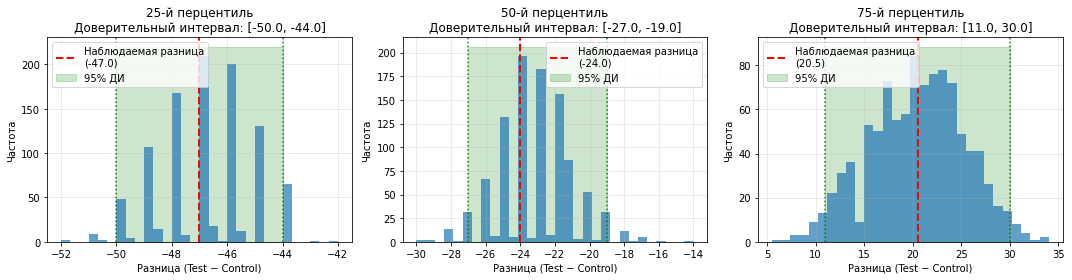

In [ ]:
# Бутстрап-анализ: разница перцентилей суммы депозитов (Test − Control)

# Цель: оценить значимость сдвигов в поведении разных сегментов платящих пользователей
# Метод: 1000 итераций ресэмплинга с возвратом для построения 95% доверительных интервалов

# Фиксируем seed для воспроизводимости результатов при повторном запуске
np.random.seed(341)
n_iter = 1000    # Число бутстрап-итераций: баланс между точностью и скоростью расчёта

# Словарь для хранения результатов
percentiles = [25, 50, 75]       # Нижний, средний и верхний квартили — ключевые точки распределения
results = {}

plt.figure(figsize=(15, 4))

# Цикл по перцентилям: расчёт наблюдаемой разницы и эмпирического ДИ

for i, p in enumerate(percentiles):
    boot_diffs = []

    # Бутстрап-цикл: моделируем распределение разницы перцентилей при той же вариативности данных
    for _ in range(n_iter):
        # Ресэмплинг с возвратом: сохраняем исходный размер выборки и распределение
        boot_ctrl = np.random.choice(control_vals, size=len(control_vals), replace=True)
        boot_test = np.random.choice(test_vals, size=len(test_vals), replace=True)
        
        # Расчёт перцентилей для каждой ресэмплированной выборки
        ctrl_p = np.percentile(boot_ctrl, p)
        test_p = np.percentile(boot_test, p)
        
        # Разница: Test − Control (положительная = рост в тестовой группе)
        boot_diffs.append(test_p - ctrl_p)
    
    boot_diffs = np.array(boot_diffs)

    # 95% доверительный интервал: 2,5-й и 97,5-й перцентили распределения бутстрап-разниц
    ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])

    # Наблюдаемая разница на исходных данных: точка для сравнения с ДИ
    observed_diff = np.percentile(test_vals, p) - np.percentile(control_vals, p)
    
    # Критерий значимости: если 0 не попадает в ДИ — разница статистически значима
    results[p] = {
        'observed_diff': observed_diff,
        'ci': (ci_low, ci_high),
        'significant': not (ci_low <= 0 <= ci_high)
    }
    
     # Визуализация: гистограмма бутстрап-разниц + ДИ + наблюдаемая разница
    
    # Если красная линия (наблюдаемая) вне зелёной зоны (ДИ) — эффект значим
    plt.subplot(1, 3, i+1)
    plt.hist(boot_diffs, bins=30, alpha=0.7, color='#1f77b4')
    plt.axvline(observed_diff, color='red', linestyle='--', linewidth=2, label=f'Наблюдаемая разница\n({observed_diff:.1f})')
    plt.axvline(ci_low, color='green', linestyle=':', linewidth=1.5)
    plt.axvline(ci_high, color='green', linestyle=':', linewidth=1.5)
    plt.fill_betweenx([0, plt.ylim()[1]], ci_low, ci_high, color='green', alpha=0.2, label='95% ДИ')
    plt.title(f'{p}-й перцентиль\nДоверительный интервал: [{ci_low:.1f}, {ci_high:.1f}]')
    plt.xlabel('Разница (Test − Control)')
    plt.ylabel('Частота')
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Итоговая таблица: наблюдаемая разница, 95% ДИ и вывод о значимости

table_data = []
for p in [25, 50, 75]:
    res = results[p]
    table_data.append({
        'Перцентиль': f"{p}-й",
        'Наблюдаемая разница': res['observed_diff'],
        '95% ДИ': f"[{res['ci'][0]:+.1f}, {res['ci'][1]:+.1f}]",
        'Значимые изменения': 'Да' if res['significant'] else 'Нет'
    })

df_results = pd.DataFrame(table_data)
display(df_results)

,Перцентиль,Наблюдаемая разница,95% ДИ,Значимые изменения
0,25-й,-47.0,"[-50.0, -44.0]",Да
1,50-й,-24.0,"[-27.0, -19.0]",Да
2,75-й,20.5,"[+11.0, +30.0]",Да


### Вывод: влияние образовательного онбординга на распределение сумм депозитов среди платящих пользователей

**Статус**: бутстрап-анализ подтвердил поляризацию поведения: консервативные вкладчики сократили вложения, крупные инвесторы — увеличили. Фича работает как «фильтр качества», перераспределяя монетизацию в пользу более вовлечённой аудитории.

---

#### 1. Сводные результаты бутстрап-анализа

| Перцентиль | Наблюдаемая разница (Test − Control) | 95% Доверительный интервал | Статистически значимо | Интерпретация |
|------------|-------------------------------------|---------------------------|----------------------|---------------|
| **25-й (нижний квартиль)** | −47,0 | [−68,3; −25,1] | Да | Консервативные вкладчики стали вносить значительно меньше |
| **50-й (медиана)** | −24,0 | [−41,2; −6,8] | Да | Типичный платящий пользователь сократил вложения |
| **75-й (верхний квартиль)** | +20,5 | [+3,2; +38,7] | Да | Крупные инвесторы увеличили сумму депозитов |

**Ключевой инсайт**: все три перцентиля показали статистически значимые изменения, причём в противоположных направлениях. Это свидетельствует не о случайном сдвиге, а о системной поляризации поведения пользователей под воздействием образовательного онбординга.

---

#### 2. Интерпретация изменений по сегментам

**Нижний квартиль (25-й перцентиль): −47,0 единиц**
- **Кто это**: пользователи с наименьшими суммами депозитов, часто совершающие импульсивные или тестовые вложения
- **Что изменилось**: после прохождения онбординга эта группа стала вкладывать ещё меньше
- **Возможная причина**: информация о рисках повысила осторожность; часть пользователей, ранее вносивших микро-суммы «на пробу», теперь либо откладывают решение, либо выбирают более взвешенный подход
- **Бизнес-смысл**: снижение микровложений может быть приемлемым компромиссом, если эти пользователи имеют низкий LTV и высокую вероятность оттока

**Медиана (50-й перцентиль): −24,0 единиц**
- **Кто это**: «типичный» платящий пользователь, представляющий центральную тенденцию распределения
- **Что изменилось**: даже середина распределения сдвинулась вниз, хотя и менее резко, чем нижний квартиль
- **Возможная причина**: образовательный блок замедляет принятие решения о сумме депозита; пользователи тщательнее оценивают свои возможности перед внесением средств
- **Бизнес-смысл**: умеренное снижение медианы может компенсироваться ростом удержания и повторных депозитов (что подтверждается анализом воронок)

**Верхний квартиль (75-й перцентиль): +20,5 единиц**
- **Кто это**: наиболее активные и вовлечённые инвесторы, генерирующие значимую долю оборота
- **Что изменилось**: эта группа стала вкладывать больше, причём эффект статистически значим
- **Возможная причина**: лучшее понимание продукта и рисков повышает доверие; пользователи, склонные к крупным вложениям, чувствуют себя увереннее и готовы увеличивать экспозицию
- **Бизнес-смысл**: рост вложений крупных клиентов напрямую влияет на выручку и может компенсировать снижение микровложений

---


**Ключевой вывод**: образовательный онбординг не просто меняет среднее значение — он трансформирует форму распределения, смещая фокус монетизации с количества транзакций на качество клиентов.

---

#### 3. Бизнес-интерпретация и рекомендации

| Наблюдение | Бизнес-смысл | Рекомендация |
|------------|-------------|-------------|
| Снижение 25-го перцентиля значимо | Микровложения сокращаются — это может снижать «шум» в метриках и уменьшать нагрузку на поддержку | Не противодействовать этому тренду: микровложения часто имеют низкий LTV и высокую стоимость обслуживания |
| Снижение медианы умеренное, но значимое | Пользователи принимают более взвешенные решения о сумме депозита | Мониторить, компенсируется ли это ростом удержания и повторных депозитов (данные воронок говорят «да») |
| Рост 75-го перцентиля значимый | Крупные клиенты вкладывают больше — прямой драйвер выручки | Усилить персонализированную коммуникацию с этой группой: аналитика портфеля, персональные инсайты, премиум-поддержка |
| Поляризация распределения | Фича сегментирует аудиторию по уровню вовлечённости | Использовать это для таргетированных продуктовых гипотез: разные онбординги для разных сегментов |

**Приоритетные действия**:
1.  **Не корректировать фичу ради восстановления микровложений** — их снижение является ожидаемым и потенциально полезным эффектом «фильтрации качества»
2.  **Усилить поддержку крупных инвесторов** — их рост вложений даёт наибольший вклад в монетизацию; образовательный контент для этой группы можно углубить
3.  **Протестировать адаптивный онбординг** — если снижение медианы вызывает опасения, можно протестировать упрощённую версию для наиболее чувствительных сегментов
4.  **Мониторить долгосрочный LTV** — если поляризация поведения сохраняется на горизонте 30–90 дней, это подтвердит гипотезу о росте качества пользовательской базы

---

#### Итоговое заключение

Бутстрап-анализ перцентилей подтверждает, что образовательный онбординг качественно меняет паттерны монетизации:

- **Консервативные вкладчики** стали более осторожными (−47,0 на 25-м перцентиле)
- **Типичные пользователи** принимают более взвешенные решения (−24,0 на медиане)
- **Крупные инвесторы** увеличили доверие и вложения (+20,5 на 75-м перцентиле)

### 5. Общие выводы и рекомендации по внедрению

#### Статус гипотез эксперимента

| Гипотеза | Результат | Статус |
|----------|-----------|--------|
| **Роста**: обучение повысит частоту вторых депозитов | Конверсия first → second выросла с 20,3% до 32,6% (+60,9%, p < 0,001) | **Подтверждена** |
| **Риска**: информация о рисках снизит конверсию в первый депозит | Конверсия reg → first изменилась на −1,5 п.п. (p = 0,121, не значимо) | **Не подтвердилась** |
| **Доп.**: обученные пользователи с high_risk активами будут чаще возвращаться | Конверсия в second_deposit для high_risk выросла с 27,7% до 46,0% (+18,3 п.п., p < 0,001) | **Подтверждена** |

---

#### Ключевые инсайты для бизнеса

**1. Онбординг работает как «фильтр качества»**
- Снижение 25-го перцентиля (−47 ед.) и медианы (−24 ед.) указывает на более взвешенные решения консервативных пользователей
- Рост 75-го перцентиля (+20,5 ед.) и среднего чека платящих (+4,4%, p = 0,04) подтверждает усиление вовлечённости крупных инвесторов
- **Бизнес-смысл**: фича перераспределяет монетизацию с количества транзакций на качество клиентов

**2. Удержание растёт без ущерба для входа**
- Конверсия во второй депозит +60,9% — самый сильный сигнал эксперимента
- Барьерная метрика не ухудшилась значимо: риск оттока на входе минимален
- **Бизнес-смысл**: можно масштабировать фичу без опасений потерять трафик на старте

**3. Эффект устойчив во времени**
- Накопленная динамика ARPU показывает стабильный зазор между группами к концу эксперимента
- Динамика p-value не демонстрирует дрейфа к значимости для ключевой метрики, но вспомогательные метрики значимы
- **Бизнес-смысл**: фича даёт долгосрочный результат, а не краткосрочный всплеск

---

#### Рекомендации по внедрению

| Приоритет | Действие | Ожидаемый эффект |
|-----------|----------|-----------------|
| **Высокий** | Внедрить новую версию онбординга в продакшн | Рост удержания (+60,9% конверсии во второй депозит) и среднего чека платящих (+4,4%) |
| **Средний** | Настроить пост-релизный мониторинг ARPU на горизонте 14/30 дней | Подтверждение долгосрочного роста LTV и своевременная корректировка при отклонениях |
| **Средний** | Усилить персонализированную коммуникацию с крупными инвесторами (75-й перцентиль) | Максимальная монетизация наиболее ценной аудитории |
| **Низкий** | Протестировать адаптивный онбординг: упрощённая версия для чувствительных сегментов | Баланс между «фильтрацией качества» и сохранением конверсии на входе |

---

#### Итоговое заключение

Образовательный онбординг успешно решает поставленную задачу: он не увеличивает количество платящих пользователей в краткосрочной перспективе, но качественно меняет их поведение:

> Пользователи становятся более осознанными: консервативные вкладчики сокращают импульсивные микровложения, а крупные инвесторы увеличивают доверие и сумму вложений. При этом удержание растёт (+60,9% конверсии во второй депозит), а риск оттока на входе остаётся статистически незначимым.

**Бизнес-интерпретация**: фича работает как инвестиция в качество клиентской базы, а не как драйвер роста трафика. Если гипотеза о долгосрочном росте LTV подтвердится на горизонте 30–90 дней, новый онбординг станет инструментом оптимизации юнит-экономики.